In [ ]:
import numpy as np
from numpy.linalg import norm
import matplotlib.pyplot as plt
import sympy as smp
import scipy as scp
from scipy.interpolate import interp1d
import locale

# Для отображения запятой вместо точки
# # 1. Set the locale to a region that uses comma decimals (e.g., German)
# locale.setlocale(locale.LC_NUMERIC, "de_DE") 
# # 2. Tell matplotlib to use the set locale
# plt.rcParams['axes.formatter.use_locale'] = True

In [48]:
class UAV:
    '''Класс летательного аппарата\n
    Параметры конструктора:\n
    mass - масса ЛА\n
    V - воздушная скорость\n
    CGposition - положение центра масс относительно передней кромки крыла в единицах средней хорды крыла\n
    WingData - кортеж, содержащий основные геомерические харакеристики крыла\n
        airfoil - строка названия файла с коэффициентами профиля крыла и точками срыва потока из XFOIL, 
        лежащего в одной дериктории с программой\n
        S - площадь крыла\n
        TaperRatio - сужение крыла\n
        AspectRatio - удлинение крыла\n
        RootChord - длина корневой хорды крыла\n
        AileronRatio - доля хорды крыла под элерон\n
        etai - расстояние от корневой хорды до начала управляющей поверхности в единицах полуразмаха\n
        etae - расстояние от корневой хорды до конца управляющей поверхности в единицах полуразмаха\n
        iw - угол установки крыла в градусах\n
    FusWidth - ширина фюзеляжа\n
    FusLength - длина фюзеляжа без учета хвостовой балки при наличии\n
    Tail - кортеж характеристик хвостового оперения\n
        Type - тип хвостового оперения\т
            "V" - V-образный\n
            "C" - традиционный\n
            "T" - T-образный\n
        Airfoil - строка названия файла с коэффициентами профиля хвоста и точками срыва потока из XFOIL\n
        HorizontalVolumeCoeff - горизонтальный объемный коэффициент\n
        VerticalVolumeCoeff - вертикальный объемный коэффициент\n
        TailArm - плечо хвостового оперение (расстояние от аэрод. центра хвоста до аэрод. центра крыла)\n
        etai - расстояние от корневой хорды до начала управляющей поверхности в единицах полуразмаха\n
        etae - расстояние от корневой хорды до конца управляющей поверхности в единицах полуразмаха\n
        it- угол установки горизонтального оперения хвоста в градусах\n
    RootChrod - длина корневой хорды крыла. Если значение ненулевое, то оно используется при дальнейших расчетах геометрии крыла
    Иначе значение коренвой хорды вычисляется согласно данным из WingData по AspectRatio, TaperRatio и S\n
    SweepQuart - стреловидность крыла. Если true, то в функции отрисовки крыла и функциях подсчета коэффициентов используются стреловидное крыло,
    иначе по умолчанию рисуется крыло трапецевидное\n
    H - высота полета, по умолчанию 0
    '''
    __rho0 = 1.225
    rho = __rho0
    __g = 9.81
    __mu = 0.0289644
    __R = 8.3144598
    T = 273 + 15
    __visc = 18e-6 # вязкость
    def __init__(self, mass, V, CGposition, WingData, FusWidth, FusLength, Tail, cr=0, SweepQuart = True, H = 0):
        self.Va = V # воздушная скорость полета
        self.H = H # высота полета Относительно чего?
        self.__mass = mass # масса ЛА
        self.W = self.__mass * self.__g # Вес ЛА
        self.S = WingData[1] # Площадь крыла
        self.d = FusWidth # Ширина фюзеляжа в  
        self.L = FusLength # Длина фюзеляжа если хостовая балка есть, то ее в длину не влючаем
        self.FusS = self.L * np.pi * self.d  + 2 * np.pi *(self.d/2)**2# Площадь поверхности фюзеляжа, подверженная обтеканию воздуха (Надо изменить) 

        self.__Ttype = Tail[0] # тип хвостового оперения 
        self.__Vht = Tail[2] # объемные коэффициенты хвостового оперения
        self.__Vvt = Tail[3]
        self.__Lt = Tail[4] # длина балки хвостового оперения (плечо хвоста) (между четвертями хорд)
        self.ART = 2 # Удлинение хвоствого оперения 
        self.TRT = 0.6 # сужение хвостового оперения

        self.__hac = 0.25 # расстояние от передней кромки крыла в ед САХ до аэродинамич центра 
        self.__hcg = CGposition # расстояние от передней кромки крыла в ед САХ до центра тяжести

        self.WingIncidenceAngle = WingData[-1]
        self.TailIncidenceAngle = Tail[-1]

        # Расчет размера крыла ###############################################
        if (cr == 0):
            self.AR = WingData[3]
            self.TR = WingData[2]
            self.c_mean = np.sqrt(self.S/self.AR)
            self.b = self.S/self.c_mean
            self.cr = self.S / (self.d + (1 + self.TR)*(self.b - self.d)/2)
            self.ct = self.cr * self.TR

        elif (cr != 0):
            self.AR = WingData[3]
            self.cr = WingData[4]
            self.c_mean = np.sqrt(self.S/self.AR)
            self.b = self.S/self.c_mean
            self.ct = 2*(self.S - self.cr*self.d)/(self.b - self.d) - self.cr
            self.TR = self.ct/self.cr
            if (self.TR >= 1):
                self.TR = 1
                self.c_mean = np.sqrt(self.S/self.AR)
                self.ct = self.c_mean
                self.cr = self.ct

        ex = np.array([1., 0])
        ey = np.array([0, 1.])
        if (SweepQuart == False):
            a = 3/4*self.cr * ex + ey * 0.5 * (self.b - self.d) + ex*1/4*self.ct - ex*self.cr
            b = 3/4*self.cr * ex + ey * 0.5 * (self.b - self.d) - ex * 3/4*self.ct
            e = b + ex*0.5*self.ct
    
            self.SweepLE = np.acos(np.dot(ey, a) / (norm(a) * norm(ey)))
            self.SweepTE = np.acos(np.dot(ey, b) / (norm(b) * norm(ey)))

            self.SweepHalf = np.acos(np.dot(ey, e - ex*0.5*self.cr) / (norm(e - ex*0.5*self.cr) * norm(ey)))
            self.SweepQuart = 0
        elif (SweepQuart == True):
            self.SweepLE = np.atan((self.cr - self.ct) / (self.b - self.d))
            self.SweepQuart = np.tan(self.SweepLE) + self.cr*0.5/(self.b - self.d) * (self.TR - 1)
            self.SweepHalf = 0

        self.__Swet = 2*self.S - 2 * (self.d * self.cr)

        # после подсчета всех основных геометрических харакеристик вычислим САХ
        # General Aviation p.328 (Есть разница для трапецевидного крыла средней хорды c и средней 
        # геометрической хорды САХ). Именно САХ используется для нормировки коэффициентов
        self.c = 2/3 * self.cr * ((self.TR)**2 + self.TR + 1)/ (self.TR + 1)
        # Положение САХ на расстоянии ymgc от корневой хорды
        self.ymgc = (self.b/6)*(1 + 2*self.TR)/(1 + self.TR)
        #########################################################################################

        # Расчет размера хвоствого оперения #####################################################
        self.Sht = self.__Vht * self.c * self.S / self.__Lt
        self.Svt = self.__Vvt * self.b * self.S / self.__Lt
        if (self.__Ttype == 'V'):
            self.Stail = self.Sht + self.Svt
            self.DihedraTail = np.atan(self.Svt/self.Sht) # rad
        self.btail = np.sqrt(self.Stail / 2  * self.ART) # высота одной лопаточки хвоста
        self.ctail_mean = self.btail / self.ART
        self.crtail = 2 * self.ctail_mean / (1 + self.TRT)
        self.cttail = self.TRT * self.crtail

        self.SweepLEtail = np.atan((self.crtail - self.cttail) / self.btail)
        self.SweepQuarttail = np.atan( 3 * (self.crtail - self.cttail) / (4 * self.btail))
        self.SweepHalftail = np.atan( (-self.cttail + self.crtail) / (2 * self.btail) )

        self.__Swettail = self.Stail * 2 # Полная площадь поверхности хвостового оперения
        self.ctail = 2/3 * self.crtail * ((self.TRT)**2 + self.TRT + 1)/ (self.TRT + 1)
        self.ymgct = (self.btail/6)*(1 + 2*self.TRT)/(1 + self.TRT)
        #########################################################################################

        # Подшрузим данные из Xfoil для профиля крыла и хвостового оперения
        self.airfoilW = WingData[0]
        # словарь для профиля крыла для разных Re
        # ключ - строка Re в тысячах
        # значение - массив данных
        self.Wdata = {}
        step = 25 # шаг числа рейнольдса в тысячах
        for i in range(0, 20):
            self.Wdata[str(step*(i+1))] = np.loadtxt('{}/{}_{}.txt'.format(self.airfoilW, self.airfoilW, step*(i+1)), skiprows = 11, dtype=float)
        # self.Wdata50 = np.loadtxt('{}_50.txt'.format(self.airfoilW), skiprows = 11, dtype=float)
        # self.Wdata100 = np.loadtxt('{}_100.txt'.format(self.airfoilW), skiprows = 11, dtype=float)
        # self.Wdata150 = np.loadtxt('{}_150.txt'.format(self.airfoilW), skiprows = 11, dtype=float)
        # self.Wdata200 = np.loadtxt('{}_200.txt'.format(self.airfoilW), skiprows = 11, dtype=float)
        # self.Wdata250 = np.loadtxt('{}_250.txt'.format(self.airfoilW), skiprows = 11, dtype=float)
        # self.Wdata300 = np.loadtxt('{}_300.txt'.format(self.airfoilW), skiprows = 11, dtype=float)
        # self.Wdata350 = np.loadtxt('{}_350.txt'.format(self.airfoilW), skiprows = 11, dtype=float)
        # self.Wdata400 = np.loadtxt('{}_400.txt'.format(self.airfoilW), skiprows = 11, dtype=float)
        # self.Wdata450 = np.loadtxt('{}_450.txt'.format(self.airfoilW), skiprows = 11, dtype=float)
        # self.Wdata500 = np.loadtxt('{}_500.txt'.format(self.airfoilW), skiprows = 11, dtype=float)

        # словарь для профиля хвоста для разных Re
        # ключ - строка Re в тысячах
        # значение - массив данных
        self.airfoilT = Tail[1] # Профиль хвостового оперения
        self.Tdata = {}
        step = 25 # шаг числа рейнольдса в тысячах
        for i in range(0, 20):
            self.Tdata[str(step*(i+1))] = np.loadtxt('{}/{}_{}.txt'.format(self.airfoilT, self.airfoilT, step*(i+1)), skiprows = 11, dtype=float)
        # self.Tdata50 = np.loadtxt('{}\{}_50.txt'.format(self.airfoilT,self.airfoilT), skiprows = 11, dtype=float)
        # self.Tdata100 = np.loadtxt('{}\{}_100.txt'.format(self.airfoilT,self.airfoilT), skiprows = 11, dtype=float)
        # self.Tdata150 = np.loadtxt('{}\{}_150.txt'.format(self.airfoilT,self.airfoilT), skiprows = 11, dtype=float)
        # self.Tdata200 = np.loadtxt('{}\{}_200.txt'.format(self.airfoilT,self.airfoilT), skiprows = 11, dtype=float)
        # self.Tdata250 = np.loadtxt('{}\{}_250.txt'.format(self.airfoilT,self.airfoilT), skiprows = 11, dtype=float)
        # self.Tdata300 = np.loadtxt('{}\{}_300.txt'.format(self.airfoilT,self.airfoilT), skiprows = 11, dtype=float)
        # self.Tdata350 = np.loadtxt('{}\{}_350.txt'.format(self.airfoilT,self.airfoilT), skiprows = 11, dtype=float)
        # self.Tdata400 = np.loadtxt('{}\{}_400.txt'.format(self.airfoilT,self.airfoilT), skiprows = 11, dtype=float)
        # self.Tdata450 = np.loadtxt('{}\{}_450.txt'.format(self.airfoilT,self.airfoilT), skiprows = 11, dtype=float)
        # self.Tdata500 = np.loadtxt('{}\{}_500.txt'.format(self.airfoilT,self.airfoilT), skiprows = 11, dtype=float)
        
        # Оставил пока эту часть для обратной совместимости, но в дальнейшем надо пользоваться 
        # функцией GetAirfoilWingData
        # self.airfoilW = WingData[0]
        # if (self.GetReynolds('MeanW') <= 250000):
        #     self.airfoilWDat = np.loadtxt('{}.txt'.format(self.airfoilW), skiprows = 11, dtype=float)
        # elif (self.GetReynolds('MeanW') > 250000 and self.GetReynolds('MeanW') <= 400000):
        #     self.airfoilWDat = np.loadtxt('{}_300.txt'.format(self.airfoilW), skiprows = 11, dtype=float)
        # elif (self.GetReynolds('MeanW') > 400000 and self.GetReynolds('MeanW') <= 600000):
        #     self.airfoilWDat = np.loadtxt('{}_500.txt'.format(self.airfoilW), skiprows = 11, dtype=float)
        # elif (self.GetReynolds('MeanW') > 500000 and self.GetReynolds('MeanW') <= 1000000):
        #     self.airfoilWDat = np.loadtxt('{}_1000.txt'.format(self.airfoilW), skiprows = 11, dtype=float)
        # self.xtop = self.airfoilWDat[:, 5]
        # self.xbot = self.airfoilWDat[:, 6]
        # self.AOA = self.airfoilWDat[:, 0] - np.ones(len(self.airfoilWDat[:, 0]))*WingData[-1] 
        # self.fxtop = interp1d(self.AOA, self.xtop) # интерполяционные функции для точки перехода
        # self.fxbot = interp1d(self.AOA, self.xbot) # от ламинарного к турбулентному течению в зависимости от угла атаки

        self.airfoilWGeo = np.loadtxt('{}\{}G.txt'.format(self.airfoilW,self.airfoilW), skiprows=1, dtype=float)
        self.thick = self.airfoilWGeo[0]
        self.thickLoc = self.airfoilWGeo[1]
        self.cam = self.airfoilWGeo[2]
        self.camLoc = self.airfoilWGeo[3]

        # self.airfoilT = Tail[1] # Профиль хвостового оперения
        # self.airfoilTDat = np.loadtxt('{}.txt'.format(self.airfoilT), skiprows = 11, dtype=float)
        # self.xtopT = self.airfoilTDat[:, 5]
        # self.xbotT = self.airfoilTDat[:, 6]
        # self.AOAT = self.airfoilTDat[:, 0] - np.ones(len(self.airfoilTDat[:, 0]))*Tail[-1] * np.cos(self.DihedraTail)
        # self.fxtopT = interp1d(self.AOAT, self.xtopT) # интерполяционные функции для точки перехода
        # self.fxbotT = interp1d(self.AOAT, self.xbotT) # от ламинарного к турбулентному течению в зависимости от угла атаки

        self.airfoilTGeo = np.loadtxt('{}\{}G.txt'.format(self.airfoilT,self.airfoilT), skiprows=1, dtype=float)
        self.thickT = self.airfoilTGeo[0]
        self.thickLocT = self.airfoilTGeo[1]
        self.camT = self.airfoilTGeo[2]
        self.camLocT = self.airfoilTGeo[3]

        self.__GetAirDensity(H)

        # Параметры управляющих поверхностей #############################################
        # TailData = (type, TailAirfoil, Vht, Vvt, Lt, cf, etaitail, etaetail, itail)
        # WingData = (WingAirfoil, S, TR, AR, cr, cf, etai, etae, iw)
        self.cfw = WingData[5] # доля хорды крыла на элероны
        self.cft = Tail[5] # доля хорды хвосового оперения на rudevator
        self.etai = WingData[6]
        self.etae = WingData[7]
        self.etaiT = Tail[6]
        self.etaeT = Tail[7]
        self.reverse = Tail[8]

        # Теоретический наклон кривой подъемного коэфф для профиля в зависимости от толщины
        thickness = [0, 0.6, 0.10, 0.14, 0.18, 0.2]
        clath = [6.3, 6.59, 6.79, 6.99, 7.19, 7.3]
        self.fClath = interp1d(thickness, clath)

        # Теоретическое значение dCl/ddelta
        thickness02 = [0, 0.04, 0.1, 0.15]
        thickness03 = [0, 0.02, 0.04, 0.06, 0.08, 0.1, 0.12, 0.15]
        cldth02 = [3.4, 3.55, 3.625, 3.75]
        cldth025 = [3.8, 3.875, 4.1, 4.25]
        cldth03 = [4.155, 4.229, 4.283, 4.352, 4.406, 4.465, 4.549, 4.609]
        
        self.Cldelta02 = interp1d(thickness02, cldth02)
        self.Cldelta025 = interp1d(thickness02, cldth025)
        self.Cldelta03 = interp1d(thickness03, cldth03)
        
        # Отношение реальной к теоретической dCl/ddelta
        Cldeltaratio02 = np.loadtxt('CldeltaRatio02.csv', skiprows=1, dtype=float, delimiter=',')[:, 3] + 0.3
        Cldeltaratio025 = np.loadtxt('CldeltaRatio025.csv', skiprows=1, dtype=float, delimiter=',')[:, 3] + 0.3
        Cldeltaratio03 = np.loadtxt('CldeltaRatio03.csv', skiprows=1, dtype=float, delimiter=',')[:, 3] + 0.3
        claRatio = np.linspace(0.7, 1, 16)

        self.CldeltaRatio02 = interp1d(claRatio, Cldeltaratio02)
        self.CldeltaRatio025 = interp1d(claRatio, Cldeltaratio025)
        self.CldeltaRatio03 = interp1d(claRatio, Cldeltaratio03)

        # Коэффициент отклонения рулей для профиля
        K02 = np.loadtxt('AirfoilFlapCoeff02.csv', dtype=float, delimiter=',', skiprows=1)[:,3]
        K025 = np.loadtxt('AirfoilFlapCoeff025.csv', dtype=float, delimiter=',', skiprows=1)[:,3]
        K03 = np.loadtxt('AirfoilFlapCoeff03.csv', dtype=float, delimiter=',', skiprows=1)[:,3]
        deflection = np.linspace(0, 40, 9)

        self.fK02 = interp1d(deflection, K02)
        self.fK025 = interp1d(deflection, K025)
        self.fK03 = interp1d(deflection, K03)

        # Коэффициент отклонения рулей для секции
        Kb = np.loadtxt('KbFlapTR05.csv', delimiter=',', dtype=float, skiprows=1)[:,3]
        eta = np.linspace(0, 1, 21)
        self.fKb = interp1d(eta, Kb)
        ##################################################################################

    def __GetAirDensity(self, h):
        self.rho = self.__rho0*np.exp(-self.__g * self.__mu * h / (self.__R * self.T))

    def GetLocalChord(self, type, y):
        '''Функция возращяет значение длины хорды крыла на расстоянии y от корневой хорды
        Функция справидлива для крыла любой трапецивидной формы (со стреловидностью и без)'''
        if (type == "Wing"):
            c_y = self.cr * (1 + 2*(self.TR - 1)*y/self.b)
        if (type == "Tail"):
            c_y = self.crtail * (1 + 2*(self.TRT - 1)*y/self.btail)
        return c_y

    def GetReynolds(self, type, x = 0, specified_V = 0):
        '''Возвращае число Рейнольдса

        "MeanW" - для САХ,

        "RootW" - для корневой хорды,

        "TipW" - для концевой хорды,

        "LocalW" - для расстояния x от корневой хорды

        "LocalT" - на расстоянии x от корня хвоста

        "Fus" - для фюзеляжа,  

        "RootT" - для корневой хорды хвоста,

        "TipT" - для концевой хорды хвоста,

        "MeanT" - для САХ хвоста

        Если число Рейнольдса превышает число Рейнольдса отрыва

        Recutoff = 38.21(c/k)**1.053

        (см. General Aviation Aircraft Design стр.682, формула (16-31))

        для поверхности c характерной норовностью k, то учитывается оно'''
        V = self.Va
        if specified_V != 0:
            V = specified_V
        kcomp = 0.2e-5 * 0.3048 # Композит
        k3d = 20e-6 # для 3д принтера 20 мкм не обработаная поверхность перпендикулярон слоям
    
        if type == 'MeanW':
            Recoff = 38.21*(self.c/kcomp)**1.053
            R = self.rho * V * self.c / self.__visc
            if R >= Recoff:
                return Recoff
            else:
                return R 
            
        if type == 'RootW':
            Recoff = 38.21*(self.cr/kcomp)**1.053
            R = self.rho * V * self.cr / self.__visc
            if R >= Recoff:
                return Recoff
            else:
                return R
            
        if type == 'TipW':
            Recoff = 38.21*(self.ct/kcomp)**1.053
            R = self.rho * V * self.ct / self.__visc
            if R >= Recoff:
                return Recoff
            else:
                return R
            
        if type == 'Fus':
            Recoff = 38.21*(self.L/kcomp)**1.053
            R = self.rho * V * self.L / self.__visc
            if R >= Recoff:
                return Recoff
            else:
                return R
        
        if type == 'LocalW':
            c_y = self.GetLocalChord(type = "Wing", y=x)
            Recoff = 38.21*(c_y/kcomp)**1.053
            R = self.rho * V * c_y / self.__visc
            if R >= Recoff:
                return Recoff
            else:
                return R
            
        if type == 'LocalT':
            c_y = self.GetLocalChord(type="Tail", y = x)
            Recoff = 38.21*(c_y/kcomp)**1.053
            R = self.rho * V * c_y / self.__visc
            if R >= Recoff:
                return Recoff
            else:
                return R
        
        if type == 'RootT':
            Recoff = 38.21*(self.crtail/kcomp)**1.053
            R = self.rho * V * self.crtail / self.__visc
            if R >= Recoff:
                return Recoff
            else:
                return R 
            
        if type == 'TipT':
            Recoff = 38.21*(self.cttail/kcomp)**1.053
            R = self.rho * V * self.cttail / self.__visc
            if R >= Recoff:
                return Recoff
            else:
                return R 
            
        if type == 'MeanT':
            Recoff = 38.21*(self.ctail/kcomp)**1.053
            R = self.rho * V * self.ctail / self.__visc
            if R >= Recoff:
                return Recoff
            else:
                return R 
        
    def GetReynoldsSpanDistribution(self, type):
        '''Функция возращает кортеж (x, Re), где 
        x - массив координат от корневой хорды крыла от 0 до b/2
        Re - массив чисел Рейнольдса, соответствующие хорде крыла на расстоянии из x'''
        step = 0.005 # шаг по размаху крыла в метрах
        if (type == "Wing"):
            x = np.linspace(0, self.b/2, (int)((self.b/2) / step)+1)
            ReDistr = np.array([])
            for el in x:
                LocRe = self.GetReynolds(type="LocalW", x=el)
                ReDistr = np.append(ReDistr, LocRe)
            return (x, ReDistr)
        if (type == "Tail"):
            x = np.linspace(0, self.btail, (int)((self.btail) / step)+1)
            ReDistr = np.array([])
            for el in x:
                LocRe = self.GetReynolds(type="LocalT", x=el)
                ReDistr = np.append(ReDistr, LocRe)
            return (x, ReDistr)

    def GetAirfoilWingData(self, y, specified_V=0):
        '''Функция возращает набор интерполяционных функция для параметров профиля крыла на расстоянии y от корневой хорды:
        коэфф. подъемной силы fCl, лобового сопротивления fCd, момента тангажа fCm, 
        точки перехода от ламинарного обтекания к турбулентному fxtopW и fxbotW. Все функции в зависимости
        от угла атаки (AOA, Cl(AOA), Cd(AOA), Cm(AOA), fxtopW(AOA), fxbotW(AOA))'''
        
        # Получим длину хорды на расстоянии y
        c_y = self.GetLocalChord(type="Wing", y=y)
        # Расчитаем число Рейнольдса для хорды на расстоянии c_y
        Re = self.GetReynolds(type="LocalW", x=y)
        if specified_V != 0:
            Re = self.GetReynolds(type="LocalW", x=y, specified_V=specified_V)
        # С учетом числа Рейнольдса выберем файл с нужными данными
        Re /= 1000
        a = Re // 25
        b = Re % 25
        if b > 12.5:
            a+=1
        Re = int(a * 25)

        airfoilWDat = self.Wdata[str(Re)]

        # if (Re >= 25000 and Re < 75000):
        #     airfoilWDat = self.Wdata50
        # if (Re >= 75000 and Re < 125000):
        #     airfoilWDat = self.Wdata100
        # if (Re >= 125000 and Re < 175000):
        #     airfoilWDat = self.Wdata150
        # if (Re >= 175000 and Re < 225000):
        #     airfoilWDat = self.Wdata200
        # if (Re >= 225000 and Re < 275000):
        #     airfoilWDat = self.Wdata250
        # if (Re >= 275000 and Re < 325000):
        #     airfoilWDat = self.Wdata300
        # if (Re >= 325000 and Re < 375000):
        #     airfoilWDat = self.Wdata350
        # if (Re >= 375000 and Re < 425000):
        #     airfoilWDat = self.Wdata400
        # if (Re >= 425000 and Re < 475000):
        #     airfoilWDat = self.Wdata450
        # if (Re >= 475000 and Re < 525000):
        #     airfoilWDat = self.Wdata500

        # угол атаки профиля в градусах
        AOA = airfoilWDat[:, 0]- np.ones(len(airfoilWDat[:, 0]))*self.WingIncidenceAngle
        # коэффициент подъемной силы
        Cl = airfoilWDat[:, 1]
        # Коэффицент лобового сопротивления
        Cd = airfoilWDat[:, 2]
        # Коэффициент момента тангажа
        Cm = airfoilWDat[:, 4]
        # точка перехода от ламинарного к турбулентному
        # для верхней и нижне частей
        xtopW =  airfoilWDat[:, 5]
        xbotW =  airfoilWDat[:, 6]

        # Интерполяционные функции для каждой из зависимостей
        return (AOA,
                interp1d(AOA, Cl), 
                interp1d(AOA, Cd), 
                interp1d(AOA, Cm), 
                interp1d(AOA, xtopW),
                interp1d(AOA, xbotW))
    
    def GetAirfoilTailData(self, y):
        '''Функция возращает набор интерполяционных функция для параметров профиля хвоста на расстоянии y от корневой хорды:
        коэфф. подъемной силы fCl, лобового сопротивления fCd, момента тангажа fCm, 
        точки перехода от ламинарного обтекания к турбулентному fxtopW и fxbotW. Все функции в зависимости
        от угла атаки (AOA, Cl(AOA), Cd(AOA), Cm(AOA), fxtopW(AOA), fxbotW(AOA))'''
        
        # Получим длину хорды на расстоянии y
        c_y = self.GetLocalChord(type="Tail", y=y)
        # Расчитаем число Рейнольдса для хорды на расстоянии c_y
        Re = self.GetReynolds(type="LocalT", x = y)

        # С учетом числа Рейнольдса выберем файл с нужными данными
        Re /= 1000
        a = Re // 25
        b = Re % 25
        if b > 12.5:
            a+=1
        Re = int(a * 25)

        airfoilTDat = self.Wdata[str(Re)]

        # # С учетом числа Рейнольдса выберем файл с нужными данными
        # if (Re >= 25000 and Re < 75000):
        #     airfoilTDat = self.Tdata50
        # if (Re >= 75000 and Re < 125000):
        #     airfoilTDat = self.Tdata100
        # if (Re >= 125000 and Re < 175000):
        #     airfoilTDat = self.Tdata150
        # if (Re >= 175000 and Re < 225000):
        #     airfoilTDat = self.Tdata200
        # if (Re >= 225000 and Re < 275000):
        #     airfoilTDat = self.Tdata250
        # if (Re >= 275000 and Re < 325000):
        #     airfoilTDat = self.Tdata300
        # if (Re >= 325000 and Re < 375000):
        #     airfoilTDat = self.Tdata350
        # if (Re >= 375000 and Re < 425000):
        #     airfoilTDat = self.Tdata400
        # if (Re >= 425000 and Re < 475000):
        #     airfoilTDat = self.Tdata450
        # if (Re >= 475000 and Re < 525000):
        #     airfoilTDat = self.Tdata500

        # угол атаки профиля в градусах
        AOA = airfoilTDat[:, 0] - np.ones(len(airfoilTDat[:, 0])) * self.TailIncidenceAngle
        # коэффициент подъемной силы
        Cl = airfoilTDat[:, 1]
        # Коэффицент лобового сопротивления
        Cd = airfoilTDat[:, 2]
        # Коэффициент момента тангажа
        Cm = airfoilTDat[:, 4]

        # точка перехода от ламинарного к турбулентному
        # для верхней и нижне частей
        xtopW =  (airfoilTDat[:, 5])
        xbotW =  (airfoilTDat[:, 6])

        Clf = interp1d(AOA, Cl)
        Cdf = interp1d(AOA, Cd)
        Cmf = interp1d(AOA, Cm)
        xtf = interp1d(AOA, xtopW)
        xbf = interp1d(AOA, xbotW)


        # Если флаг для перевернутого профиля хвостового оперения активен
        # Надо относительно нулевого угла атаки отразить характеристики профиля
        # Но так как данные необязательно получены симметрично относительно нуля
        # нужно выбрать минимальный угол атаки по модулю, обрезать данные по нему
        # симметрично, а затем сделать np.flip массивов
        if self.reverse == True:
            a_upr = AOA[-1]
            a_btm = AOA[0]
            if abs(a_btm) <= a_upr:
                AOA = AOA[AOA <= abs(a_btm)] # проверить на правильность

                Cl = -Clf(-AOA)
                Clf = interp1d(AOA, Cl)
                Cd = Cdf(-AOA)
                Cdf = interp1d(AOA, Cd)
                Cm = -Cmf(-AOA)
                Cmf = interp1d(AOA, Cm) 
                xb = xbf(AOA)
                xbf = interp1d(AOA, xb)
                xt = xtf(AOA)
                xtf = interp1d(AOA, xt)
        

        # Интерполяционные функции для каждой из зависимостей
        return (AOA,
                Clf,
                Cdf,
                Cmf,
                xtf,
                xbf)

    def GetSkinFriction(self, type, side, y=0, AOA=0,):
        '''Функция считает коэффициент силы трения в приближении
        турбулентного-ламинароного обтекания тела при угле атаки AOA в градусах
        на расстоянии y от корневой хорды крыла или хвоста
        
        'Fus' - для фюзеляжа,

        "Wing" - для крыла,

        "Tail" - для хвоста,

        side = "Top", "Bottom"
        '''
        if (type == "Tail"):
            # получим число рейнольдса на расстоянии y
            Re = self.GetReynolds("LocalT", y)
            # Получим длину хорды на расстоянии y
            c_y = self.GetLocalChord(type, y)
            if (side == "Top"):
                # получим функцию точки перехода от ламинарного к турбулентному для верхней части профиля
                fxt = self.GetAirfoilTailData(y)[4]
                x0 = 36.9*fxt(AOA * np.cos(self.DihedraTail))**0.625 * (1/Re)**0.375
                return 0.074/(Re**0.2) * (1 - (fxt(AOA* np.cos(self.DihedraTail)) - x0))**0.8
            if (side == "Bottom"):
                # аналогично для нижней части профиля
                fxb = self.GetAirfoilTailData(y)[5]
                x0 = 36.9*fxb(AOA* np.cos(self.DihedraTail))**0.625 * (1/Re)**0.375
                return 0.074/(Re**0.2) * (1 - (fxb(AOA* np.cos(self.DihedraTail)) - x0))**0.8
            
        elif (type == 'Wing'):
            Re = self.GetReynolds("LocalW", y)
            if side == 'Top':
                # функция распределния точки перехода от ламинарного к турбулентному от угла атаки
                # для верхней части профиля
                fxt = self.GetAirfoilWingData(y)[4]
                x0 = 36.9 * fxt(AOA)**0.625 * (1/Re)**0.375
                return 0.074/(Re**0.2) * (1 - (fxt(AOA) - x0))**0.8
            elif side == 'Bottom':
                # функция распределния точки перехода от ламинарного к турбулентному от угла атаки
                # для нижней части профиля
                fxb = self.GetAirfoilWingData(y)[5]
                x0 = 36.9 * fxb(AOA)**0.625 * (1/Re)**0.375
                return 0.074/(Re**0.2) * (1 - (fxb(AOA) - x0))**0.8
            
        else: # Для фюзеляжа взял оценку, что переход от ламинарного к турбулентному потоку происходит почти сразу
              # на рассоянии лишь 1% от общей длины фюзеляжа
            Re = self.GetReynolds("Fus")
            x0 = 36.9 * 0.01**0.625 * (1/Re)**0.375 
            return 0.074/(Re**0.2) * (1 - (0.01 - x0))**0.8

    def GetCDmin(self, crud = 1.25, AOA = 0, distr = False):
        '''Функция подсчитывает минимальный коэффициент лобового сопротивления для всего самолета
        на основе геометрических характеристик крыла, хвостового оперения и фюзеляжа'''
        # Сопротивление крыла #################
        Ctip = 0.5 * (self.GetSkinFriction(type='Wing', side='Top', y = self.b/2, AOA = AOA) + self.GetSkinFriction(type='Wing', side='Bottom', y = self.b/2, AOA = AOA))
        Croot = 0.5 * (self.GetSkinFriction(type='Wing', side='Top', y = 0, AOA = AOA) + self.GetSkinFriction(type='Wing', side='Bottom', y = 0, AOA = AOA))
        Cfw = Croot + 2*self.ymgc/self.b * (Ctip - Croot) # Cfw = 0.5 * (Croot + Ctip) # было как полусумма корневой и концевой. 
        # Решил заменить на выражение по закону эффективности из General Aviation p. 
        Cdw = (self.__Swet / self.S) * Cfw

        # if (abs(self.thickLoc - 0.3) <=0.05):
        #     FFw = 1 + 2*(self.thick) + 60(self.thick)**4
        # elif (self.thickLoc >= 0.4 and self.thickLoc <= 0.5):
        #     FFw = 1 + 1.2*(self.thick) + 70(self.thick)**4
        FFw = (3.3*(self.thick) - 0.008*(self.thick)**2 + 27*(self.thick)**3)*(np.cos(self.SweepHalf))**2 + 1
        IFw = 1.05
        Cdw = FFw * Cdw * IFw
        #######################################

        # Сопротивление фюзеляжа ##############
        # f = self.L/2 * np.sqrt(4 / self.d**2) # Это формула для тел вращения, но если в поперечном сечении
        # не круг, то стоит использовать формулу ниже
        # f = self.L / np.sqrt(self.CrossFusS) # CrossFusS - площадь поперечного сечения фюзеляжа
        f = self.L / np.sqrt(self.d * (self.d))
        ReF = self.GetReynolds(type='Fus')
        IFf = 1.0
        if (ReF <= 1e5):
            Cdf = 1.328/(ReF)**0.5 * (1 + f**-1.5) + 0.11*f**-2
        elif (ReF > 1e5):
            FFf1 = 1 + 1.5*f**-1.5 + 7*f**-3
            FFf2 = 1 + 2.2*f**-1.5 + 3.8*f**-3
            
            FFf3 = 1 + 60*f**-3 + f/400 #This provides a good correlation for fineness ratios 
            #(f) above 6 as is typical for high-speed and military aircraft, but 
            #seems to overestimate drag for fineness ratios much below 5.

            FFf4 = 2.939 - 0.7666*f + 0.1328*f**2 - 0.01074*f**3 + 3.275e-4*f**4
            FFf5 = 1 + 2.2*f**-1.5 - 0.9*f**-3
            FFf6 = 0.9 + 5*f**-1.5 + f/400 # From Raymer

            if (f > 5): # Исключил выпадающее значение FFf3 при малых finess ratio
                FFf = np.mean([FFf1, FFf2, FFf3, FFf4, FFf5, FFf6])
            else:
                FFf = np.mean([FFf1, FFf2, FFf4, FFf5, FFf6])
            Cdf = self.GetSkinFriction(type='Fus', side = 'Top') * FFf * (self.FusS) / self.S * IFf
        #######################################

        # Сопротивление хвостового оперения ##################
        Ctiptail = 0.5 * (self.GetSkinFriction(type='Tail', side='Top', y=self.btail, AOA = AOA) + self.GetSkinFriction(type='Tail', side='Bottom', y=self.btail, AOA = AOA))
        Croottail = 0.5 * (self.GetSkinFriction(type='Tail', side='Top', y=0, AOA = AOA) + self.GetSkinFriction(type='Tail', side='Bottom', y=0, AOA = AOA))
        Cft = Croottail + self.ymgct/self.btail * (Ctiptail - Croottail) # Cft = 0.5 * (Croottail + Ctiptail)
        Cdt = self.__Swettail / self.S * Cft
        FFt = (3.3*(self.thickT) - 0.008*(self.thickT)**2 + 27*(self.thickT)**3)*(np.cos(self.SweepHalftail))**2 + 1
        IFt = 1.03
        Cdt = IFt * Cdt * FFt
        ######################################################
        if (distr == False):
            return (Cdf + Cdw + Cdt)*crud
        else:
            return (Cdf*crud, Cdw*crud, Cdt*crud)

# Далее идут функции для расчета профильных характеристик крыла
# Если крыло не прямое, то характеристику какого профиля брать? корневого?
# концевого? или САХ? Эти функции высчитывают характеристики по методу эффективности
# из General Aviation p. , усредняя по размаху профильные характеристики 
# AOA в параметрах функций - это угол атаки самолета?
    def GetAirfoilCl(self, AOA, type):
        '''Возвращает значение коэффициента подъемной
        силы профиля для заданного угла атаки
        type = "Wing" - для профиля крыла
        type = "Tail" - для профиля хвоста'''
        if (type == "Wing"):
            # получим интерполяционную функцию для корневой хорды
            fCl_root = self.GetAirfoilWingData(0)[1]
            Cl_root = fCl_root(AOA)
            # для концевой
            fCl_tip = self.GetAirfoilWingData(self.b/2)[1]
            Cl_tip = fCl_tip(AOA)
            # Усредгим по закону эффективности
            Cl = Cl_root + 2*self.ymgc/self.b*(Cl_tip - Cl_root)
            return Cl
        elif (type == "Tail"):
            # получим интерполяционную функцию для корневой хорды
            fCl_root = self.GetAirfoilTailData(0)[1]
            Cl_root = fCl_root(AOA* np.cos(self.DihedraTail))
            # для концевой
            fCl_tip = self.GetAirfoilTailData(self.btail)[1]
            Cl_tip = fCl_tip(AOA* np.cos(self.DihedraTail))
            # Усредгим по закону эффективности
            Cl = Cl_root + self.ymgct/self.btail*(Cl_tip - Cl_root)
            return Cl
    
    def GetAirfoilCd(self, AOA, type):
        '''Возвращает значение коэффициента силы 
        лобового сопротивления профиля для заданного угла атаки
        type = "Wing" - для профиля крыла
        type = "Tail" - для профиля хвоста'''
        if (type == "Wing"):
            fCd_root = self.GetAirfoilWingData(0)[2]
            Cd_root = fCd_root(AOA)
            fCd_tip = self.GetAirfoilWingData(self.b/2)[2]
            Cd_tip = fCd_tip(AOA)
            Cd = Cd_root + 2*self.ymgc/self.b*(Cd_tip - Cd_root)
            return Cd
        elif (type == "Tail"):
            # получим интерполяционную функцию для корневой хорды
            fCd_root = self.GetAirfoilTailData(0)[2]
            # угол атаки для сомолета, нужно делать поправку на угол раствора лопаток V-образного хвоста
            Cd_root = fCd_root(AOA* np.cos(self.DihedraTail))
            # для концевой
            fCd_tip = self.GetAirfoilTailData(self.btail)[2]
            Cd_tip = fCd_tip(AOA* np.cos(self.DihedraTail))
            # Усредгим по закону эффективности
            Cd = Cd_root + self.ymgct/self.btail*(Cd_tip - Cd_root)
            return Cd
    
    def GetAirfoilCd0(self, type):
        '''Возвращает значение коэффициента силы 
        лобового сопротивления профиля для 0 угла атаки
        type = "Wing" - для профиля крыла
        type = "Tail" - для профиля хвоста'''
        if (type == "Wing"):
            fCd_root = self.GetAirfoilWingData(0)[2]
            Cd_root = fCd_root(0)
            fCd_tip = self.GetAirfoilWingData(self.b/2)[2]
            Cd_tip = fCd_tip(0)
            Cd = Cd_root + 2*self.ymgc/self.b*(Cd_tip - Cd_root)
            return Cd
        elif (type == "Tail"):
            # получим интерполяционную функцию для корневой хорды
            fCd_root = self.GetAirfoilTailData(0)[2]
            # угол атаки для сомолета, нужно делать поправку на угол раствора лопаток V-образного хвоста
            Cd_root = fCd_root(0)
            # для концевой
            fCd_tip = self.GetAirfoilTailData(self.btail)[2]
            Cd_tip = fCd_tip(0)
            # Усредгим по закону эффективности
            Cd = Cd_root + self.ymgct/self.btail*(Cd_tip - Cd_root)
            return Cd
    
    def GetAirfoilCdmin(self, type):
        '''Функция возвращает значение минимального коэффициента лобового
        сопротивления и угла атаки, при котором это достигается для профиля

        type = 'Wing' - для профиля крыла

        type = 'Tail' - для профиля хвостового оперения'''
        cur_root = 10
        cur_tip = 10
        curr = 10
        a_root = 0
        a_tip = 0
        a = 0
        if (type == "Wing"):
            # получим зависиость от угла атаки профильного 
            # коэффициента лобового сопротивления крыла
            # и пройдемся по углам атаки и найдем минимум
            for el in np.linspace(-5, 5, 10000):
                #Cd_root = self.GetAirfoilWingData(0)[2](el)
                #Cd_tip = self.GetAirfoilWingData(self.b/2)[2](el)
                Cd = self.GetAirfoilCd(el, "Wing")
                if (Cd < curr):
                    curr = Cd
                    a = el
                # if (Cd_root < cur_root):
                #     cur_root = Cd_root
                #     a_root = el
                # if (Cd_tip < cur_tip):
                #     cur_tip = Cd_tip
                #     a_tip = el 
            
            # Cdmin = cur_root + 2*self.ymgc/self.b*(cur_tip - cur_root)
            # print ("Cdmin_root = ", cur_root, "\nCdmin_tip = ", cur_tip, "\nCdmin = ", curr,
                #    "\na_root = ", a_root, "\na_tip = ", a_tip, "\na = ", a)
            return (a, curr)

        elif (type == "Tail"):
            for el in np.linspace(-5, 5, 10000):
                #Cd_root = self.GetAirfoilTailData(0)[2](el)
                #Cd_tip = self.GetAirfoilTailData(self.b/2)[2](el)
                Cd = self.GetAirfoilCd(el, "Tail")
                if (Cd < curr):
                    curr = Cd
                    a = el
                # if (Cd_root < cur_root):
                #     cur_root = Cd_root
                #     a_root = el
                # if (Cd_tip < cur_tip):
                #     cur_tip = Cd_tip
                #     a_tip = el 
            
            # Cdmin = cur_root + self.ymgct/self.btail*(cur_tip - cur_root)
            # print ("Cdmin_root = ", cur_root, "\nCdmin_tip = ", cur_tip, "\nCdmin = ", curr,
                #    "\na_root = ", a_root, "\na_tip = ", a_tip, "\na = ", a)
            return (a, curr)
        
            # как было 
            # alpha = self.AOAT
            # Cd = self.airfoilTDat[:, 2]
            # fCd = interp1d(alpha, Cd)
            # for el in np.linspace(-5, 10, 10000):
            #     if (fCd(el) < cur):
            #         cur = fCd(el)
            #         a = el
            # return (a / self.DihedraTail, cur)
    
    def GetAirfoilCm(self, AOA, type):
        '''Функция возращает значение профильного коэффициента момента тангажа для выбранного угла атаки'''
        if (type == "Wing"):
            fCm_root = self.GetAirfoilWingData(0)[3]
            Cm_root = fCm_root(AOA)
            fCm_tip = self.GetAirfoilWingData(self.b/2)[3]
            Cm_tip = fCm_tip(AOA)
            Cm = Cm_root + 2*self.ymgc/self.b*(Cm_tip - Cm_root)
            return Cm
        elif (type == "Tail"):
            fCm_root = self.GetAirfoilTailData(0)[3]
            Cm_root = fCm_root(AOA* np.cos(self.DihedraTail))
            fCm_tip = self.GetAirfoilTailData(self.btail)[3]
            Cm_tip = fCm_tip(AOA* np.cos(self.DihedraTail))
            Cm = Cm_root + self.ymgct/self.btail*(Cm_tip - Cm_root)
            return Cm
        
            # как было
            # alpha = self.AOAT
            # Cm = self.airfoilTDat[:, 4]
            # fCm = interp1d(alpha, Cm)
            # return fCm(AOA * np.cos(self.DihedraTail))
    
    def GetAirfoilClmax(self, type):
        # Усреднять по методу эффективности Cl, а потом искать его максимум?
        # или найти максимум выбранного профиля, а потом по методу эффективности усреднить, найденные Clmax?
        # Тут сейчас первый вариант. Разница между методами в третьем знаке после точки
        cur_root = 0
        cur_tip = 0
        curr = 0
        a_root = 0
        a_tip = 0
        a = 0
        if (type == "Wing"):
            # получим зависиость от угла атаки профильного 
            # коэффициента лобового сопротивления крыла
            # и пройдемся по углам атаки и найдем минимум
            for el in np.linspace(0, self.GetAirfoilWingData(0)[0][-1], 10000):
                Cl_root = self.GetAirfoilWingData(0)[1](el)
                Cl_tip = self.GetAirfoilWingData(self.b/2)[1](el)
                Cl = self.GetAirfoilCl(el, "Wing")
                if (Cl > curr):
                    curr = Cl
                    a = el
                # if (Cl_root > cur_root):
                #     cur_root = Cl_root
                #     a_root = el
                # if (Cl_tip > cur_tip):
                #     cur_tip = Cl_tip
                #     a_tip = el 
            
            # Clmax = cur_root + 2*self.ymgc/self.b*(cur_tip - cur_root)
            # print ("Clmax_root = ", cur_root, "\nClmax_tip = ", cur_tip, "\nClmax = ", curr,
            #        "\na_root = ", a_root, "\na_tip = ", a_tip, "\na = ", a)
            return (a, curr)

        elif (type == "Tail"):
            for el in np.linspace(0, self.GetAirfoilTailData(0)[0][-1], 10000):
                #Cl_root = self.GetAirfoilTailData(0)[1](el)
                #Cl_tip = self.GetAirfoilTailData(self.btail)[1](el)
                Cl = self.GetAirfoilCl(el, "Tail")
                if (Cl > curr):
                    curr = Cl
                    a = el
                # if (Cl_root > cur_root):
                #     cur_root = Cd_root
                #     aroot = el
                # if (Cl_tip > cur_tip):
                #     cur_tip = Cd_tip
                #     a_tip = el 
            
            # Clmax = cur_root + self.ymgct/self.btail*(cur_tip - cur_root)
            # print ("Clmax_root = ", cur_root, "\nClmax_tip = ", cur_tip, "\nClmax = ", curr,
                #    "\na_root = ", a_root, "\na_tip = ", a_tip, "\na = ", a)
            return (a, curr)
            # как было
            # return (a / self.DihedraTail, curr)
    
    def GetAirfoilCl0(self, type):
        '''Возвращает коэффициент подъемной силы профиля
        при нулевом угле атаки'''
        if (type == 'Wing'):
            Cl = self.GetAirfoilCl(0, type)
            return Cl
        elif (type == 'Tail'):
            Cl = self.GetAirfoilCl(0, type)
            return Cl
            # как было
            # alpha = self.AOAT
            # Cl = self.airfoilTDat[:, 1]
            # fCl = interp1d(alpha, Cl)
            # return fCl(0)

    def GetAirfoilClslope(self, AOA, type):
        '''Возвращает наклон кривой подъемного коэффициента
        профиля в 1/рад'''
        if (type == "Wing"):
            return (self.GetAirfoilCl(AOA+0.05, type) - self.GetAirfoilCl(AOA, type)) / (0.05*np.pi/180)
        elif (type == "Tail"):
            return (self.GetAirfoilCl((AOA+0.05)*np.cos(self.DihedraTail), type) - self.GetAirfoilCl(AOA*np.cos(self.DihedraTail), type)) / (0.05*np.pi/180)

            # как было
            # alpha = self.AOAT
            # Cl = self.airfoilTDat[:, 1]
            # fCl = interp1d(alpha, Cl)
            # return (-fCl(AOA * self.DihedraTail) + fCl(AOA * self.DihedraTail + 0.1))/0.1 *180/np.pi
        
    #def GetAirfoilClmaxDistribution(self):

    def GetCLmax(self, type = 0):
        '''Функция возращает максимальный коэффициен подъемной силы крыла
        type = 0 - CL = 0.9*cos(L)*Clmax из General Aviation p. 371
        type = 1 - интегрирование по размаху профильного коэффициента подъемной силы из General Aviation p. 371
        метод 1 пока не реализован'''
        if type == 0:
            return 0.9 * np.cos(self.SweepQuart) * self.GetAirfoilClmax(type='Wing')[1]
        if type == 1:
            #Получим распределение профильного максимального коэффицента подъемной силы по размаху
            self.GetAirfoilClmax("Wing")

    def GetCL0(self, type):
         az = (-1)*self.GetAirfoilCl0(type=type)/self.GetAirfoilClslope(AOA=0, type=type)
         return abs(az)*self.GetCLslope(type)

    def GetZeroLiftAOA(self):
        '''Возращает угол атаки нулевой подъемной силы в радианах'''
        return (-1)*self.GetAirfoilCl0(type="Wing")/self.GetAirfoilClslope(AOA=0, type="Wing")
    
    def GetCLcruise(self):
        return self.GetCL0('Wing') + self.W/(self.GetDynamicPressure() * self.S) + self.GetCLslope('Wing')*self.GetZeroLiftAOA()
    
    def GetDynamicPressure(self):
        self.__GetAirDensity(self.H)
        if self.Va != 0:
            return self.rho * self.Va**2 / 2
        else:
            return self.rho * self.GetCruiseSpeed()**2 / 2
    
    def GetSpeedSound(self):
        return np.sqrt(1.4 * self.__R * self.T/self.__mu)
    
    def GetCLslope(self, type, AOA=0):
        """Расчитывает наклон кривой коэффициента подъемной силы
        для секции крыла в 1/rad"""
        if (type == 'Wing'):
            beta = 1 - (self.Va/self.GetSpeedSound())**2 # В формулах из книг - это beta**2
            k = self.GetAirfoilClslope(AOA=AOA, type=type) / (2*np.pi)
            x = self.AR/k * (beta + np.tan(self.SweepHalf)**2)**0.5
            eta = 0.98
            return 2*np.pi*self.AR / (2 + np.sqrt(x**2 + 4))*eta
        elif (type == 'Tail'):
            beta = 1 - (self.Va/self.GetSpeedSound())**2
            k = self.GetAirfoilClslope(AOA=AOA, type=type) / (2*np.pi)
            x = self.ART/k * (beta + np.tan(self.SweepHalftail)**2)**0.5
            eta = 0.98
            return 2*np.pi*self.ART / (2 + np.sqrt(x**2 + 4))*eta
    
    def GetOsvald(self, type, method = 'A'):
        if (type == 'Wing'):
            if (method == 'A'):
                return 2 / (2 - self.AR + np.sqrt(4 + self.AR**2*(1 + np.tan(self.SweepQuart)**2)))
            if (method == 'B'):
                r = 0.38 - self.SweepLE * 57.3/3000 + (self.SweepLE * 57.3)**2/15000
                u = 0.98
                t = self.d / self.b
                CDmin = self.GetCDmin()
                return 1 / (np.pi*self.AR*r*CDmin + 1 / ((1 + 0.03*t - 2*t**2)*u))
        
        elif (type == 'Tail'):
            if (method == 'A'):
                return 2 / (2 - self.ART + np.sqrt(4 + self.ART**2*(1 + np.tan(self.SweepQuarttail)**2)))
            if (method == 'B'):
                r = 0.38 - self.SweepLEtail * 57.3/3000 + (self.SweepLEtail * 57.3)**2/15000
                u = 0.98
                t = self.d / self.btail # отношение ширины фюзеляжа к размаху. Для крыла работает. Но справидливо ли для хвоста?
                CDmin = self.GetCDmin()
                return 1 / (np.pi*self.ART*r*CDmin + 1 / ((1 + 0.03*t - 2*t**2)*u))
            
    def GetTotalLiftCoefficient(self, AOA, deflecW, deflecT, distr = 'All'):
        CLw = self.GetCL0("Wing") + self.GetCLslope('Wing') * AOA/57.3
        CLdeltaw = self.GetCLdelta('Wing', deflecW)
        CLt = (self.GetCL0("Tail") + self.GetCLslope('Tail') * AOA/57.3) 
        print(self.GetCL0("Wing") + self.GetCL0("Tail")*self.Sht / self.S* np.cos(self.DihedraTail))
        print(self.GetCLslope('Wing') + self.GetCLslope('Tail')*self.Sht / self.S* np.cos(self.DihedraTail))
        # Нужно ли домножать на 2? Так как геомерические характеристики задаются для одной лопатки хвостового оперения,
        # то, вероятно, надо домножить на 2, но это не влияет на балансировочные кривые. Хотя При вычислении суммарного
        # кофф подъемной силы, учитываем двойную площадь хвостового оперения self.Sht
        CLdeltat = self.GetCLdelta('Tail', deflecT)
        # коэффициенты считаю для хвоста с учетом угла раствора для одной лопатки, но тут умнажаю на площадь горизонтальную,
        # соответсвующую двум лопаткам, никакие двойки не нужны. Ниже умножаю на косинус угла раствора, чтобы получить вклад в вертикальном направлении
        CLtotal = CLw + CLdeltaw + self.Sht / self.S * (CLt + CLdeltat) * np.cos(self.DihedraTail)
        if (distr == "Wing"):
            return (CLw)
        if (distr == "Tail"):
            return CLt
        else:
            return CLtotal
    
    def GetCLmaxTotal(self, type = 0):
        CLmw = self.GetCLmax()
        CLmt = 0.9 * np.cos(self.SweepQuarttail) * self.GetAirfoilClmax(type='Tail')[1] * self.Sht / self.S * np.cos(self.DihedraTail)
        return CLmw + CLmt
    
    def GetStallSpeed(self):
        '''Функция подсчитывает скорость сваливания 
        методом последовательных приближений'''
        CLm = self.GetCLmaxTotal()
        Epsilon = 0.1
        Vp = self.Va
        Vs =np.sqrt(2*self.W / (self.rho * self.S * CLm))
        while abs(Vp - Vs) >= Epsilon:
            curr = 0
            al = 0
            # получим зависиость от угла атаки профильного 
            # коэффициента лобового сопротивления крыла
            # и пройдемся по углам атаки и найдем минимум
            for el in np.linspace(0, self.GetAirfoilWingData(0, Vs)[0][-1], 10000):
                Cl_root = self.GetAirfoilWingData(0, Vs)[1](el)
                Cl_tip = self.GetAirfoilWingData(self.b/2, Vs)[1](el)
                Cl = self.GetAirfoilCl(el, "Wing")
                if (Cl > curr):
                    curr = Cl
                    al = el
            CLm = 0.9 * np.cos(self.SweepQuart) * curr
            Vp = Vs
            Vs =np.sqrt(2*self.W / (self.rho * self.S * CLm))
        return Vs

            
    def GetAirfoilCldelta(self, type, deflec):
        '''Функция принимает тип (type) поверхности, для которой необходимо
        расчитать производную коэфф подъемной силы профиля по отклонению рулей
        при заданном отклонении рулей на угол deflec. Положительный 
        соответствует отколонению рулей вниз
        
        type = 'Wing' - для крыла,
        
        type = 'Tail' - для хвостового оперения'''
        if (type == 'Wing'):
            Clatheory = self.fClath(self.thick)
            # claRatio = self.GetAirfoilClslope(AOA=AOA, type=type) / Clatheory
            claRatio = 0.85
            if (claRatio >1):
                claRatio = 1
            if (claRatio < 0.7):
                claRatio = 0.7

            if (abs(self.cfw - 0.2) < 0.025):
                CldeltaRatio = self.CldeltaRatio02(claRatio)
                Cldeltath = self.Cldelta02(self.thick)
                K = self.fK02(abs(deflec))
            elif (abs(self.cfw - 0.25) < 0.025):
                CldeltaRatio = self.CldeltaRatio025(claRatio)
                Cldeltath = self.Cldelta025(self.thick)
                K = self.fK025(abs(deflec))
            elif (abs(self.cfw - 0.3) < 0.025):
                CldeltaRatio = self.CldeltaRatio03(claRatio)
                Cldeltath = self.Cldelta03(self.thick)
                K = self.fK03(abs(deflec))
            return CldeltaRatio * Cldeltath * K * deflec/57.3
       
            
        elif (type == 'Tail'):
            Clatheory = self.fClath(self.thickT)
            # claRatio = self.GetAirfoilClslope(AOA=AOA, type=type) / Clatheory # из-за нелинейности профиля дает сбои
            # заменил на данные из DATCOM для отношения коэфф. подъемной силы профиля
            claRatio = 0.85
            if (claRatio > 1):
                claRatio = 1

            if (abs(self.cft - 0.2) < 0.025):
                CldeltaRatio = self.CldeltaRatio02(claRatio)
                Cldeltath = self.Cldelta02(self.thickT)
                K = self.fK02(abs(deflec))
            elif (abs(self.cft - 0.25) < 0.025):
                CldeltaRatio = self.CldeltaRatio025(claRatio)
                Cldeltath = self.Cldelta025(self.thickT)
                K = self.fK025(abs(deflec))
            elif (abs(self.cft - 0.3) < 0.025):
                CldeltaRatio = self.CldeltaRatio03(claRatio)
                Cldeltath = self.Cldelta03(self.thickT)
                K = self.fK03(abs(deflec))
            return CldeltaRatio * Cldeltath * K * deflec/57.3
            
    def GetCLdelta(self, type, deflec):
        deltaCldelta = self.GetAirfoilCldelta(type = type, deflec=deflec)
        a = 1.05
        b = self.GetCLslope(type) / self.GetAirfoilClslope(type=type, AOA=0)
        if (type == 'Tail'):
            Kb = self.fKb(self.etaeT) - self.fKb(self.etaiT)
            return deltaCldelta * a * b * Kb # * np.cos(self.DihedraTail) учел в функции GetTotalLiftCoefficient
        else:
            Kb = self.fKb(self.etae) - self.fKb(self.etai)
            return deltaCldelta * a * b * Kb
        
    def GetTotalDragCoefficient(self, AOA, deflec, distr = "All"):
        if (distr == "Wing"):
            CD0 = self.GetCDmin(distr=True)[1]
            CDi = (self.GetTotalLiftCoefficient(AOA, deflecW=0, deflecT=0, distr="Wing"))**2 / (self.AR * self.GetOsvald(type='Wing', method='B') * np.pi)
            return (CD0,CDi)
        
        CD0 = self.GetCDmin()
        CDi = (self.GetTotalLiftCoefficient(AOA, deflecW=0, deflecT=0))**2 / (self.AR * self.GetOsvald(type='Wing', method='B') * np.pi)
        CDd = 0.0006 * abs(deflec) # Взял из оценок из General Aviation. По модулю отклонение рулей, так как отрицательным коэфф.
        # лобового оспроивления быть не может
        return (CD0 + CDi + CDd)

    def GetCLminD(self):
        '''Функция возращает коэффициент подъемной силы при
        минимальном кооэффициенте лобового сопротивления (CLminD, CDmin, alpha)'''
        a = np.linspace(-10,10,100)
        cur_min = 10
        cur = 0
        CLminD = 0
        alpha_min = 0
        for el in a:
            cur = self.GetCDmin(crud = 1.25, AOA=el)
            if cur < cur_min:
                cur_min = cur
                alpha_min = el
        CLminD = self.GetTotalLiftCoefficient(alpha_min, 0, 0)
        return (CLminD, cur_min, alpha_min)  
             
    def GetCm(self, AOA, deflec, distr = False):
        '''Функция подсчитывает коэффициент момента тангажа'''
        # q = self.GetDynamicPressure()
        # CL0 = self.GetCL0("Wing") + self.GetCL0("Tail")
        # CLalpha = self.GetCLslope('Wing') + self.GetCLslope('Tail')*self.Sht / self.S # 1/rad
        # CLde = 6.071771678986001e-05 # 1/rad
        # CDde = 0.02 # 1/rad
        # CLminD = self.GetCLminD()
        # CDalpha = 2*CLalpha/(np.pi*self.AR*self.GetOsvald('Wing', 'B'))*(CL0 - CLminD) 
        # CDmin = self.GetTotalDragCoefficient(AOA, deflec) - CDalpha*AOA/57.3 - CDde*deflec
        # print(CDmin, CDalpha)
        
        # Крыло #######################
        # DATCOM 4.1.4.1-b предлагается полуссума корневого и концевого Cm, функция GetAirfoilCm учитывает форму крыла и
        # считает по методу эффективности
        Cm0w = self.GetAirfoilCm(AOA, "Wing") * ( (self.AR * np.cos(self.SweepQuart)**2) / (self.AR + 2*np.cos(self.SweepQuart)) )
        Cm0w += self.GetCL0('Wing')*(self.__hcg - self.__hac)
        Cmalphaw = self.GetCLslope('Wing', AOA) * (self.__hcg - self.__hac)
        #####################################

        # Хвост ###############################
        Cm0t = self.GetAirfoilCm(AOA=0, type='Tail') * ( (self.ART * np.cos(self.SweepQuarttail)**2) / (self.ART + 2*np.cos(self.SweepQuarttail)) )* (self.Sht / self.S) * (self.ct / self.c)
        Ltcg = self.__Lt / self.c + 0.25 - self.__hcg # Плечо хвостового оперения от четверти хорды хвоста до центра тяжести 
        Cm0t += self.GetCL0('Tail') * (Ltcg) * (self.Sht / self.S) # последние два множителя отвечают за приведение 
        # коэффициента момента тангажа для того чтобы сложить с коэффициентом момента тангажа для крыла

        eta = 0.9 # Ослабление динамического давления у хвоста
        dEdalpha = 0.1 #2 * self.GetCLslope('Wing', AOA) / (np.pi * self.AR) # отклонение потока крылом в области у хвостового оперения
        Cmalphat = -eta * self.Sht / self.S * Ltcg * self.GetCLslope('Tail', AOA)*(1 - dEdalpha)
        if (deflec == 0):
            Cmdelatt = 0
        else:
            Cmdelatt = -self.GetCLdelta('Tail', deflec) / (deflec/57.3) * eta * (self.Sht / self.S) * Ltcg
        ########################################

        # Пропеллер ############################
        Pn = np.loadtxt("NormalForceAeroNaut1180.txt", dtype=float, delimiter=',')
        Vel = Pn[:,0]
        Pn = Pn[:,1]
        Pn = interp1d(Vel, Pn)(self.Va) # производная нормальной силы пропеллера по углу атаки
        xt = 0.3 # плечо нормальной силы до цента тяжести

        Zprop = 50e-3
        T = 3
        # T = CD/np.cos(AOA/57.3)*Q*self.S
        # if (T < 0):
        #     T = 0
        Cm0prop = -T*Zprop / (self.GetDynamicPressure()*self.S*self.c)
        Cmpropalpha = Pn * xt / (self.GetDynamicPressure()*self.S*self.c)
        ########################################

        # CM0 = Cm0w + Cm0t
        # CMalpha = Cmalphaw + Cmalphat
        # CMde = Cmdelatt

        # A = np.array([[CDalpha, CDde, -1/(q*self.S)],[CLalpha, CLde, 0],[CMalpha, CMde, Zprop/(q*self.S*self.c)]])
        # b = np.array([[-CDmin], [self.W/(q*self.S) - CL0], [-xt*Pn*AOA/57.3/(q*self.S*self.c) - CM0]])

        # res = np.linalg.solve(A, b)
        # print(res)
        if (distr == True):
            print("Cm0w = ", Cm0w)
            print("Cm0t = ", Cm0t)
            print("Cmoprop = ", Cm0prop)
            print("Cmalphaw = ", Cmalphaw)
            print("Cmalphat = ", Cmalphat)
            print("Cmalphaprop = ", Cmpropalpha)
            print("Cmaeltat = ", Cmdelatt)
            return (Cm0w+Cmalphaw* (AOA/57.3), Cm0t+Cmalphat* (AOA/57.3), Cm0prop)
        else:
            return Cm0w + Cm0t + Cm0prop + (Cmalphaw + Cmalphat + Cmpropalpha) * (AOA/57.3) + Cmdelatt * (deflec / 57.3)

    def GetCn(self, AOS):
        '''Функция подсчитывает коэффициент момента рыскания 
        за счет хвостового оперения'''
        # Угол скольжения приводит к появлению угла атаки для лопаток хвостового оперения
        AOA = AOS*np.sin(self.DihedraTail)

        ##### Вклад крыла #####
        # Для выскополана вклад последнего слагаемого 0.0115 1/rad
        # для низкого крыла 0, для среднего 0.0057
        Cnbeta_wing = 0.00344*1*np.sqrt(self.SweepQuart) + 0.0115

        ##### Вклад вертикального хвоста #####
        # Коэффициент подъемной силы V-образного оперения
        # внутри функция GetAirfoilClslope вызывает GetAirfoilCl, которая получает угол атаки самолета
        # если вызову с нулем, то получу наклон при нулевом угле атаки нормально лопаткам
        # домнажаю на синус - получаю в нормальном направлении коэфф
        CLbeta = self.GetAirfoilClslope(0, 'Tail')*np.sin(self.DihedraTail)
        Lcg = self.__Lt + 0.25 - self.__hcg
        eta = 0.9
        dsigmadbeta = 0.1
        Cnbeta = (self.Svt/self.S) * (Lcg/self.b) * (1 + dsigmadbeta) * eta * CLbeta

        return (Cnbeta + Cnbeta_wing)*AOS/57.3

    def GetNeutralPoint(self, AOA):
        '''Функция возвращает положение центра давления в единицах САХ крыла'''
        Ltcg = self.__Lt / self.c + 0.25 - self.__hcg
        return self.__hac + 0.9 * self.Sht / self.S * Ltcg * self.GetCLslope('Tail', AOA) / self.GetCLslope('Wing', AOA) * (1 - 0.1)

    def GetStaticMargin(self, AOA):
        xn = self.GetNeutralPoint(AOA)
        SM = xn - self.__hcg
        return SM

    def PlotWing(self):
        '''Функция рисует крыло с условными 
        обозначениями центра масс, центра давления и аэродинамического центра'''
        fig, ax = plt.subplots(1,1, figsize = ((210-45)/25.4,6))
        ax.set_xlim(-self.b/2*1.1, self.b/2*1.1 +0.35)
        ax.set_ylim(-0.01*self.cr, 1.*self.cr)
        ax.set_aspect('equal')
        ax.hlines(0, 0, self.d/2, color = 'black')
        ax.hlines(self.cr, 0, self.d/2, color='black')
        ax.vlines(self.d/2, 0, self.cr, color = 'black', linestyles='--')
        ax.plot([self.d/2, self.b/2,], [0, self.cr/2 - self.ct/2], color = 'black')
        ax.plot([self.d/2, self.b/2,], [self.cr, self.cr/2 + self.ct/2], color='black')
        ax.vlines(self.b/2, self.cr/2 - self.ct/2, self.cr/2 + self.ct/2, color = 'black')
        ax.hlines(0, 0, -self.d/2, color = 'black')
        ax.hlines(self.cr, 0, -self.d/2, color='black')
        ax.vlines(-self.d/2, 0, self.cr, color = 'black', linestyles='--')
        ax.plot([-self.d/2, -self.b/2,], [0, self.cr/2 - self.ct/2], color = 'black')
        ax.plot([-self.d/2, -self.b/2,], [self.cr, self.cr/2 + self.ct/2], color='black')
        ax.vlines(-self.b/2, self.cr/2 - self.ct/2, self.cr/2 + self.ct/2, color = 'black')

        hnp = self.GetNeutralPoint(AOA=0)*self.c
        ax.scatter(0, hnp, c='y', s = 5, label='ЦД={}'.format(round(hnp, 3)))
        ax.scatter(0, self.__hcg * self.c, s = 5, c = 'black', label = 'ЦМ={}'.format(round(self.__hcg * self.c, 3)))
        ax.scatter(0, self.c * self.__hac, c = 'r', s = 5, label='АЦ={}'.format(round(self.c * self.__hac, 3)))
        ax.legend(loc='upper right', fontsize=7)
        ax.set_axis_off()
        ax.text(-0.18, -0.05, 'Передняя кромка', size=7)
        # plt.savefig('Wing.png', dpi=300, bbox_inches='tight', pad_inches=0.01)

    def PlotVn(self, n_up, n_down):
        '''Функция отрисовывает V-n диаграмму согласно 
        Авиационным правилам часть 25. Зеленой областью
        отмечена рабочий диапазон перегрузок и скоростей'''
        figv, axv = plt.subplots(1,1, figsize=((210-45)/25.4,3.5))
        axv.spines['left'].set_position('zero')
        axv.spines['right'].set_color('none')
        axv.spines['bottom'].set_position('zero')
        axv.spines['top'].set_color('none')
        Vcruise = self.Va
        CLmax = self.GetCLmaxTotal() # бех механизации
        CLmax_mech = self.GetTotalLiftCoefficient(AOA=12, deflecT=20, deflecW=20) # макс коэф под силы с выпущенными элеронами
        # CLmin = self.GetCLminTotal()
        CLmin = -0.5
        Vdive = 1.4*Vcruise
        axv.vlines(Vdive, n_down, n_up, color='black')
        axv.hlines(0, 0, Vdive, linewidth = 1, color='black')
        Vstall_no_mech_up = np.sqrt( 2 * self.W / (self.rho * self.S * CLmax)) # скорость сваливания с убранными закрылками
        Vstall_no_mech_down = np.sqrt( 2 * self.W / (self.rho * self.S * abs(CLmin)))
        print(Vstall_no_mech_down) # скорость сваливания с убранными закрылками
        VA = np.sqrt(n_up) * Vstall_no_mech_up # Скорость маневренная, не меньше этого согласно АП25
        axv.hlines(n_up, 0, Vdive, linestyles='--', color = 'black', linewidth=1)
        axv.hlines(n_down, 0, Vdive, linestyles='--', color = 'black', linewidth=1)
        axv.vlines(Vcruise, 0, n_up, linestyles='--', color='black', linewidth=1)
        V = np.linspace(0, Vdive, 1000)

        # Вепхняя линия без механиз ########################################################################
        for i in range(1000):
            if (abs(V[i]**2*CLmax*self.S/self.W - n_up) <= 0.01):
                end_up= i
            if (abs((V[i]**2 - Vstall_no_mech_up**2) *CLmax*self.S/self.W) <= 0.01):
                start_up = i

        axv.plot(V[start_up:end_up], V[start_up:end_up]**2*CLmax*self.S/self.W, color = 'black')
        axv.plot(V[0:start_up], V[0:start_up]**2*CLmax*self.S/self.W, '--',color = 'black', linewidth=1)
        if (VA >= V[end_up]):
            VA = V[end_up]
            # axv.scatter(VA, n_up, c='red', s=7)
            axv.vlines(VA, 0, n_up, color='black', linestyles='--',linewidth=1)
        else:
            # axv.scatter(VA, VA**2*CLmax*self.S/self.W, c='red', s=7)
            axv.vlines(VA, 0, VA**2*CLmax*self.S/self.W, color='black', linestyles='--',linewidth=1)

        axv.vlines(Vstall_no_mech_up, 0, Vstall_no_mech_up**2*CLmax*self.S/self.W, color='black')
        #########################################################################################

        # Верхняя линия с мех ##################################################################
        for i in range(1000):
            if (abs(V[i]**2*CLmax_mech*self.S/self.W - n_up) <= 0.01):
                end_up_mech= i
            if (abs((V[i]**2 - Vstall_no_mech_up**2) *CLmax_mech*self.S/self.W) <= 0.01):
                start_up_mech = i
        axv.plot(V[0:end_up_mech], V[0:end_up_mech]**2*CLmax_mech*self.S/self.W, '-.', color='black')

        # Нижняя линия ##########################################################################
        for i in range(1000):
            if (abs(V[i]**2*CLmin*self.S/self.W - n_down) <= 0.01):
                end_down= i
            # if (abs((V[i]**2 - Vstall_no_mech_down**2) *CLmin*self.S/self.W) <= 0.01):
            #     start_down = i

        axv.plot(V[0:end_down], V[0:end_down]**2*CLmin*self.S/self.W, color = 'black')
        # axv.plot(V[0:start_down], V[0:start_down]**2*CLmin*self.S/self.W, '--',color = 'black')
        #########################################################################################

        axv.set_xticks(ticks=[Vstall_no_mech_up, VA, Vcruise, Vdive], labels=[r'$V_{s}$'+'={}'.format(round(Vstall_no_mech_up,1)), r'$V_{A}=$'+'{}'.format(round(VA,1)), r'$V_{C}=$'+'{}'.format(round(Vcruise,1)), r'$V_{D}=$'+'{}'.format(round(Vdive,1))])
        axv.hlines(n_up, V[end_up], Vdive, color='black')
        axv.hlines(n_down, V[end_down], Vdive, color='black')
        axv.set_xlim(0, Vdive+0.1)
        axv.set_ylim(n_down-0.1, n_up+0.2)
        axv.text(2.5, 2.5, 'опущенные элероны')
        axv.fill([Vstall_no_mech_up,Vstall_no_mech_up, VA, Vdive, Vdive, Vstall_no_mech_down, Vstall_no_mech_down], [0, Vstall_no_mech_up**2*CLmax*self.S/self.W, VA**2*CLmax*self.S/self.W, n_up, n_down, n_down, 0], color='green', alpha=0.6)
        # plt.savefig('Vn.png', dpi=300, bbox_inches = 'tight', pad_inches=0.01)

    def GetParameters(self):
        '''Функция выводит геометрические характеристики
        крыла и хвостового оперения'''
        print('Крыло #############################')
        print('Sw = {}'.format(round(self.S, 3)))
        print('bw = {}'.format(round(self.b, 3)))
        print('cw = {}'.format(round(self.c, 3)))
        print('crw = {}'.format(round(self.cr, 3)))
        print('AR = {}'.format(round(self.AR, 3)))
        print('TR = {}'.format(round(self.TR, 3)))
        print('iw = {}'.format(round(self.WingIncidenceAngle, 3)))
        print('###################################' + '\n')

        print('Хвостовое оперение #################')
        print('St = {}'.format(round(self.Stail, 3)))
        print('bt = {}'.format(round(self.btail, 3)))
        print('ct = {}'.format(round(self.ctail, 3)))
        print('crt = {}'.format(round(self.crtail, 3)))
        print('ctt = {}'.format(round(self.cttail, 3)))
        print('ARt = {}'.format(round(self.ART, 3)))
        print('TRt = {}'.format(round(self.TRT, 3)))
        print('gamma='+'{}'.format(round(self.DihedraTail*57.3, 0)))
        print('it = {}'.format(round(TailData[-1], 3)))
        print('Lt = {}'.format(round(self.__Lt, 3)))
        print('###################################' + '\n')

        print('Круиз ##############################')
        CLc = self.GetTotalLiftCoefficient(0,0,0)
        CD = self.GetTotalDragCoefficient(0,0)
        print('CLc = {}'.format(CLc))
        Vc = np.sqrt(2*self.W / (self.rho * CLc*self.S))
        print('Vc = {}'.format(Vc))
        print('CD = {}'.format(CD))
        print("T = {}".format(self.rho*Vc*Vc/2*CD*self.S))
        print("Vstall = {}".format(self.GetStallSpeed()))
        print('CLminD = {}'.format(self.GetCLminD()))

    def PlotPowerCurves(self):
        '''Функция рисует зависимость располагаемой и потребной тяги'''


In [49]:
S = 0.38
WingAirfoil = "SD7032"
TR = 1
AR = 8
cr = 0.230
cf = 0.3
iw = 1 # угол установки крыла
etai = 0. # координата начала элеронов в ед полуразмаха
etae = 0.5 # координата конца элеронов в ед полуразмаха
WingData = (WingAirfoil, S, TR, AR, cr, cf, etai, etae, iw)

type = 'V'
TailAirfoil = 'SD8020'
Vht = 0.60 # объемный коэффициент горизонтального оперения
Vvt = 0.04 # объемный коэффициент вертикального оперения
Lt = 0.9 # плечо хвоста расстояние между четвертями хорд крыла и хвоста
itail = 0.5 # Угол установки хвостового оперения (кажется инвертируется знак при первернутом профиле)
cf = 0.3
etaitail = 0.05 # координата начала руля высоты в ед полуразмаха
etaetail = 0.95 # координата конца руля высоты в ед полуразмаха
reverse = False # Флаг перевернутости профиля
TailData = (type, TailAirfoil, Vht, Vvt, Lt, cf, etaitail, etaetail, reverse, itail)

hcg = 0.1 # координата ценра масс от передней кромки в ед хорды
p = UAV(mass = 3.5, V = 18, CGposition = hcg, WingData=WingData, FusWidth=0.17, FusLength= 0.7, Tail = TailData, SweepQuart=False)
# plt.plot(p.GetAirfoilTailData(0)[0], p.GetAirfoilTailData(0)[1](p.GetAirfoilTailData(0)[0]))
# plt.grid()
# p.GetCm(0, 1, True)
# p.GetParameters()
# aos = np.linspace(-5, 5, 11)
# Cn = []
# for el in aos:
#     Cn.append(p.GetCn(el))
# plt.plot(aos, Cn)
# plt.grid()
# re = p.GetReynoldsSpanDistribution('Wing')
# plt.plot(re[0], re[1])
p.GetTotalLiftCoefficient(0,0,0), 

0.45177714474668207
5.106520206932833


(np.float64(0.45177714474668207),)

0.45177714474668207
5.106520206932833
0.45177714474668207
5.106520206932833
0.45177714474668207
5.106520206932833
0.45177714474668207
5.106520206932833
0.45177714474668207
5.106520206932833
0.45177714474668207
5.106520206932833
0.45177714474668207
5.106520206932833
0.45177714474668207
5.106520206932833
0.45177714474668207
5.106520206932833
0.45177714474668207
5.106520206932833
0.45177714474668207
5.106520206932833
0.45177714474668207
5.106520206932833
0.45177714474668207
5.106520206932833
0.45177714474668207
5.106520206932833
0.45177714474668207
5.106520206932833
0.45177714474668207
5.106520206932833
0.45177714474668207
5.106520206932833
0.45177714474668207
5.106520206932833
0.45177714474668207
5.106520206932833
0.45177714474668207
5.106520206932833
0.45177714474668207
5.106520206932833
0.45177714474668207
5.106520206932833
0.45177714474668207
5.106520206932833
0.45177714474668207
5.106520206932833
0.45177714474668207
5.106520206932833
0.45177714474668207
5.106520206932833
0.4517771447

(None, np.float64(0.496872707268064))

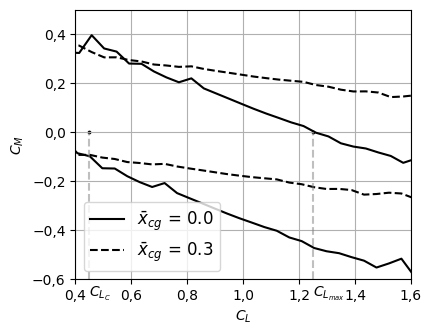

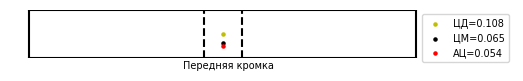

In [ ]:

plt.figure(figsize=(110/25.4, 3.5))
hcg = 0.0 # координата ценра масс от передней кромки в ед хорды
p = UAV(mass = 3.5, V = 18, CGposition = hcg, WingData=WingData, FusWidth=0.17, FusLength= 0.7, Tail = TailData, SweepQuart=False)
a = np.linspace(-10, 10, 41)
CM_0 = []
CM_10 = []
CL_0 = []
CL_10 = []
for el in a:
    CM_0.append(p.GetCm(el, 15))
    CM_10.append(p.GetCm(el, -15))
    CL_0.append(p.GetTotalLiftCoefficient(el, 15, -15))
    CL_10.append(p.GetTotalLiftCoefficient(el, 15, 15))
plt.plot(CL_0, CM_0, color='black', label = r"$\bar{x}_{cg}$ = "+"{}".format(hcg))
plt.plot(CL_10, CM_10,color='black')

# hcg = 0.0 # координата ценра масс от передней кромки в ед хорды
# p = UAV(mass = 3.5, V = 18, CGposition = hcg, WingData=WingData, FusWidth=0.17, FusLength= 0.7, Tail = TailData, SweepQuart=False)
# CM_0 = []
# CM_10 = []
# CL_0 = []
# CL_10 = []
# for el in a:
#     CM_0.append(p.GetCm(el, 15))
#     CM_10.append(p.GetCm(el, -15))
#     CL_0.append(p.GetTotalLiftCoefficient(el, 15, -15))
#     CL_10.append(p.GetTotalLiftCoefficient(el, 15, 15))
# plt.plot(CL_0, CM_0, color='green', label = r"$x_{cg}$ = "+"{}".format(hcg))
# plt.plot(CL_10, CM_10, color='green')

# hcg = 0.1 # координата ценра масс от передней кромки в ед хорды
# p = UAV(mass = 3.5, V = 18, CGposition = hcg, WingData=WingData, FusWidth=0.17, FusLength= 0.7, Tail = TailData, SweepQuart=False)
# CM_0 = []
# CM_10 = []
# CL_0 = []
# CL_10 = []
# for el in a:
#     CM_0.append(p.GetCm(el, 15))
#     CM_10.append(p.GetCm(el, -15))
#     CL_0.append(p.GetTotalLiftCoefficient(el, 15, -15))
#     CL_10.append(p.GetTotalLiftCoefficient(el, 15, 15))
# plt.plot(CL_0, CM_0, color = 'orange', label = r"$x_{cg}$ = "+"{}".format(hcg))
# plt.plot(CL_10, CM_10, color = 'orange')

hcg = 0.3 # координата ценра масс от передней кромки в ед хорды
p = UAV(mass = 3.5, V = 18, CGposition = hcg, WingData=WingData, FusWidth=0.17, FusLength= 0.7, Tail = TailData, SweepQuart=False)
CM_0 = []
CM_10 = []
CL_0 = []
CL_10 = []
for el in a:
    CM_0.append(p.GetCm(el, 15))
    CM_10.append(p.GetCm(el, -15))
    CL_0.append(p.GetTotalLiftCoefficient(el, 15, -15))
    CL_10.append(p.GetTotalLiftCoefficient(el, 15, 15))
plt.plot(CL_0, CM_0, '--', label = r"$\bar{x}_{cg}$ = " + '{}'.format(hcg), color = 'black')
plt.plot(CL_10, CM_10, '--', color = 'black')

plt.grid()
# plt.scatter(p.GetCLmaxTotal(), 0)
plt.legend(fontsize=12)
plt.xlim(0.4, 1.6)
plt.ylim(-0.6, 0.5)
plt.xlabel(r"$C_L$")
plt.ylabel(r"$C_{M}$")
plt.vlines(1.25, -0.6, 0, colors='gray', linestyles='--', alpha=0.5)
plt.vlines(0.45, -0.6, 0, colors='gray', linestyles='--', alpha=0.5)
plt.scatter(1.25, 0, c='black', s=3)
plt.scatter(0.45, 0, c='black', s=3)
plt.text(1.25, -0.67, r'$C_{L_{max}}$')
plt.text(0.45, -0.67, r'$C_{L_{С}}$')
plt.savefig("CM(CL).png", dpi=300, bbox_inches='tight', pad_inches=0)
p.PlotWing(), p.GetNeutralPoint(AOA=0)

Text(0, 0.5, '$C_{M}$')

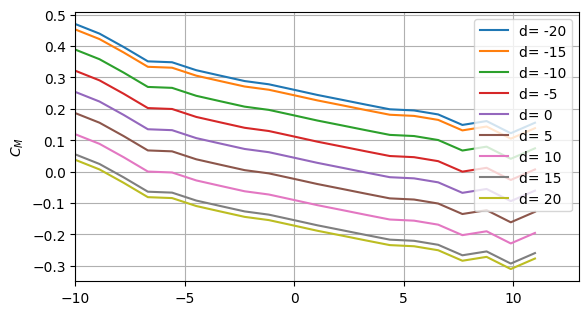

In [23]:
fig, ax = plt.subplots(1,1, figsize=((210-45)/25.4,3.5))
hcg = 0.3
p = UAV(mass = 3.5, V = 18, CGposition = hcg, WingData=WingData, FusWidth=0.17, FusLength= 0.7, Tail = TailData, SweepQuart=False)
a = np.linspace(-10, 11, 20)
defl = [-20, -15, -10, -5, 0, 5, 10, 15, 20]
cm = []
for d in defl:
    for el in a:
        cm.append(p.GetCm(el, d))
    ax.plot(a, cm, label='d= {}'.format(d))
    cm = []    

ax.legend()
ax.grid('Major')
ax.set_xlim(-10, 13)
# ax.text(9.7, 0.01,r'$\delta_{e} = -20^{o}$')
# ax.text(11.2, -0.03,r'$-15^{o}$')
# ax.text(11.2, -0.07,r'$-10^{o}$')
# ax.text(11.2, -0.12,r'$-5^{o}$')
# ax.text(11.7, -0.16,r'$0^{o}$')
# ax.text(11.7, -0.21,r'$5^{o}$')
# ax.text(11.7, -0.25,r'$10^{o}$')
# ax.text(11.7, -0.29,r'$15^{o}$')
# ax.text(11.7, -0.33,r'$20^{o}$')
# ax.set_xlabel(r'$\alpha, ^{o} $')
ax.set_ylabel(r'$C_{M}$')
# plt.savefig('BalanceCurve.png', dpi = 300, bbox_inches = 'tight', pad_inches=0.01)
# на расстояние между линиями влияет доля размаха хвостового оперения, занимаемого рулями

0.42664884264149583
5.41566317883905
0.42664884264149583
5.41566317883905
DCL =  0.16229709669163517
0.42664884264149583
5.41566317883905
0.45177714474668207
5.106520206932833
DCL =  0.45177714474668207
0.45177714474668207
5.106520206932833
0.45177714474668207
5.106520206932833


(np.float64(0.02094647944860646),
 np.float64(0.8109762555948675),
 (np.float64(0.35275600441445726),
  np.float64(0.02040797543187555),
  np.float64(-1.1111111111111107)))

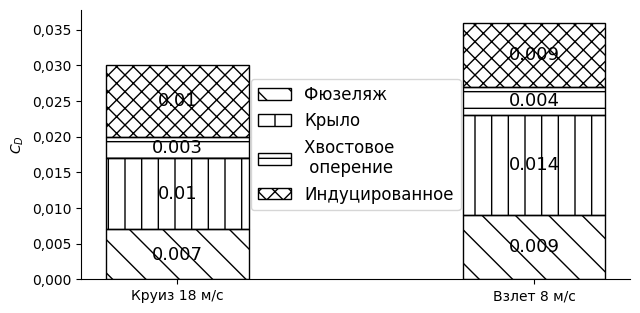

In [54]:
S = 0.38
WingAirfoil = "SD7032"
TR = 1
AR = 8
cr = 0.230
cf = 0.3
iw = 1 # угол установки крыла
etai = 0. # координата начала элеронов в ед полуразмаха
etae = 0.5 # координата конца элеронов в ед полуразмаха
WingData = (WingAirfoil, S, TR, AR, cr, cf, etai, etae, iw)

type = 'V'
TailAirfoil = 'SD8020'
Vht = 0.60 # объемный коэффициент горизонтального оперения
Vvt = 0.04 # объемный коэффициент вертикального оперения
Lt = 0.9 # плечо хвоста расстояние между четвертями хорд крыла и хвоста
itail = 0.5 # Угол установки хвостового оперения (кажется инвертируется знак при первернутом профиле)
cf = 0.3
etaitail = 0.05 # координата начала руля высоты в ед полуразмаха
etaetail = 0.95 # координата конца руля высоты в ед полуразмаха
reverse = False # Флаг перевернутости профиля
TailData = (type, TailAirfoil, Vht, Vvt, Lt, cf, etaitail, etaetail, reverse, itail)

hcg = 0.2 # координата ценра масс от передней кромки в ед хорды

p = UAV(mass = 3.5, V = 8, CGposition = hcg, WingData=WingData, FusWidth=0.15, FusLength= 0.7, Tail = TailData, SweepQuart=False)
Cd0fto, Cd0wto, Cd0tto = p.GetCDmin(distr=True, crud=1.25)
print("DCL = ",p.GetTotalLiftCoefficient(0, 0, 0)-p.GetCLminD()[0])
inducedDragto = (p.GetTotalLiftCoefficient(0, 0, 0))**2 / (p.GetOsvald('Wing', method='B') * np.pi * p.AR) 

p = UAV(mass = 3.5, V = 18, CGposition = hcg, WingData=WingData, FusWidth=0.15, FusLength= 0.7, Tail = TailData, SweepQuart=False)
Cd0f, Cd0w, Cd0t = p.GetCDmin(distr=True, crud=1.25)
print("DCL = ",p.GetTotalLiftCoefficient(0, 0, 0))
inducedDrag = (p.GetTotalLiftCoefficient(0, 0, 0))**2 / (p.GetOsvald('Wing', method='B') * np.pi * p.AR) 

fig, ax = plt.subplots(1,1, figsize = ((180)/25.4, 3.5))
labels = ['Круиз 18 м/с', 'Взлет 8 м/c']
Drag = {
    'Фюзеляж': np.array([round(Cd0f,3), round(Cd0fto,3)]),
    'Крыло': np.array([round(Cd0w,3), round(Cd0wto,3)]),
    'Хвостовое \n оперение': np.array([round(Cd0t,3), round(Cd0tto,3)]),
    'Индуцированное': np.array([round(inducedDrag,3), round(inducedDragto,3)])
}
width = 0.4 
bottom = np.zeros(2)
hatches = ['/', '\\', '|', '-', 'xx']
i = 0
for comp, num in Drag.items():
    i+=1
    x = ax.bar(labels, num, width, label=comp, bottom=bottom, hatch=hatches[i], fill=False)
    bottom += num

    ax.bar_label(x, label_type='center', color='black', size=13,)
    
ax.legend(loc='center', fontsize=12)
ax.set_ylabel(r'$C_{D}$')
ax.spines[['right', 'top']].set_visible(False)
# plt.savefig('DragDistributionTO.png', dpi=300, bbox_inches = 'tight', pad_inches = 0.)
p.GetCDmin(), p.GetOsvald(type = 'Wing',method='B'), p.GetCLminD()

np.float64(340.20838428886486)

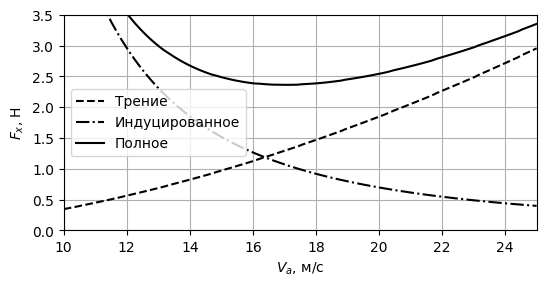

In [ ]:
inD = []
Cd0 = []
Cpara = []
hcg = 0.2
for v in np.linspace(7, 25, 100):
    p = UAV(mass = 3.5, V = v, CGposition = hcg, WingData=WingData, FusWidth=0.17, FusLength= 0.7, Tail = TailData, SweepQuart=False)
    Cd0.append(p.GetCDmin() * p.GetDynamicPressure() * p.S)
    Cpara.append(p.GetCDmin())
    inducedDrag = p.W**2 / (p.GetDynamicPressure() * np.pi * p.b**2 * p.GetOsvald(type='Wing', method='B'))
    inD.append(inducedDrag)

fig, ax = plt.subplots(1,1, figsize = ((155)/25.4, 2.8))

ax.plot(np.linspace(10, 25, 100), Cd0, '--', label = 'Трение', color='black')
ax.plot(np.linspace(10, 25, 100), inD, '-.',label = 'Индуцированное', color='black')
ax.plot(np.linspace(10, 25, 100), np.array(inD) + np.array(Cd0), label = 'Полное', color='black')
ax.set_ylim(0, 3.5)
ax.set_xlim(10, 25)
ax.grid()
ax.set_xlabel(r'$V_{a}$, м/с')
ax.set_ylabel(r'$F_{x}$, H')
# ax.set_title('Зависимость силы лобового сопротивления от воздушной скорости')
ax.legend()
plt.savefig('Drag(V).png', dpi=300, bbox_inches = 'tight', pad_inches = 0.)
p.GetSpeedSound()

#### Исследование влияния удлинения крыла на качество аэродинамическое

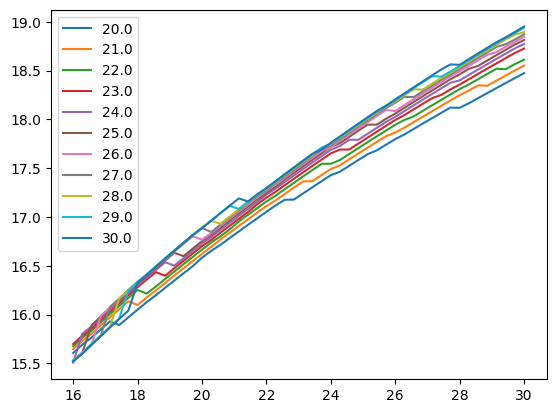

In [ ]:
ar_arr = np.linspace(20, 30, 11)
K = []
K_cur = []
vel = np.linspace(16,30)
for ar in ar_arr:
    for v in vel:
        S = 0.38
        WingAirfoil = "SD7032"
        TR = 1
        AR = ar
        cr = 0.230
        cf = 0.3
        iw = 1 # угол установки крыла
        etai = 0.5 # координата начала элеронов в ед полуразмаха
        etae = 1 # координата конца элеронов в ед полуразмаха
        WingData = (WingAirfoil, S, TR, AR, cr, cf, etai, etae, iw)

        type = 'V'
        TailAirfoil = 'SD8020'
        Vht = 0.60 # объемный коэффициент горизонтального оперения
        Vvt = 0.04 # объемный коэффициент вертикального оперения
        Lt = 0.8 # плечо хвоста расстояние между четвертями хорд крыла и хвоста
        itail = 0.5 # Угол установки хвостового оперения (кажется инвертируется знак при первернутом профиле)
        cf = 0.3
        etaitail = 0.1 # координата начала руля высоты в ед полуразмаха
        etaetail = 0.9 # координата конца руля высоты в ед полуразмаха
        reverse = False # Флаг перевернутости профиля
        TailData = (type, TailAirfoil, Vht, Vvt, Lt, cf, etaitail, etaetail, reverse, itail)

        hcg = 0.2 # координата ценра масс от передней кромки в ед хорды
        p = UAV(mass = 3.5, V = v, CGposition = hcg, WingData=WingData, FusWidth=0.17, FusLength= 0.7, Tail = TailData, SweepQuart=True)
        K_cur.append(p.GetTotalLiftCoefficient(0,0,0)/p.GetTotalDragCoefficient(0,0))
    plt.plot(vel, K_cur, label = '{}'.format(ar))
    K_cur.clear()
plt.legend()

#### Ислледование влияния параметров крыла на балансировочные кривые

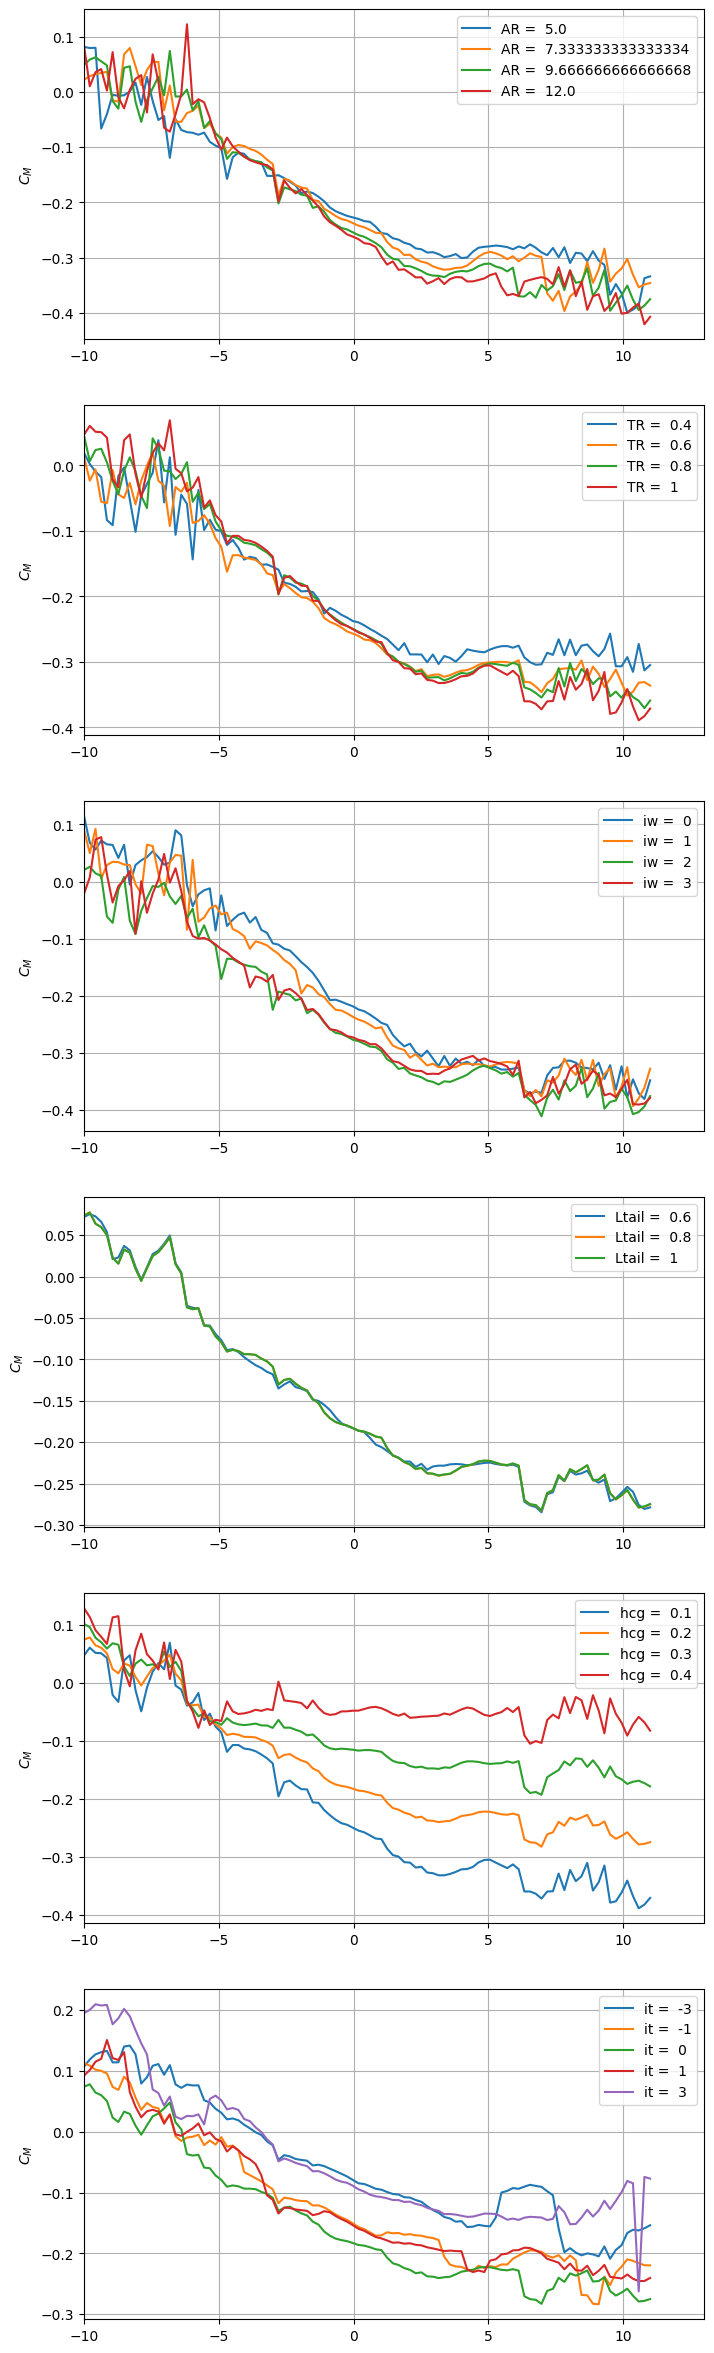

In [ ]:
fig, ax = plt.subplots(6,1, figsize = (8,30))
ax = ax.ravel()
hcg = 0.1
ar = np.linspace(5, 12, 4) 
tr = [0.4, 0.6, 0.8, 1]
Iwing = [0, 1, 2, 3]
Ltail = [0.6, 0.8, 1]
a = np.linspace(-10, 11, 100)
CGpos = [0.1, 0.2, 0.3, 0.4]
Itail = [-3, -1, 0, 1, 3]
SM = []
cm = []
for asrat in ar:
    for el in a:
        S = 0.346
        WingAirfoil = "SG6043"
        TR = 1
        AR = asrat
        cr = 0.236
        cf = 0.3
        iw = 1.8 # угол установки крыла
        etai = 0.5 # координата начала элеронов в ед полуразмаха
        etae = 1 # координата конца элеронов в ед полуразмаха
        WingData = (WingAirfoil, S, TR, AR, cr, cf, etai, etae, iw)
        p = UAV(mass = 3.5, V = 18, CGposition = hcg, WingData=WingData, FusWidth=0.2, FusLength= 0.7, Tail = TailData, SweepQuart=False)
        cm.append(p.GetCm(el, 0))
    ax[0].plot(a, cm, label = "AR =  {}".format(asrat))
    cm = []

for tapr in tr:
    for el in a:
        S = 0.346
        WingAirfoil = "SG6043"
        TR = tapr
        AR = 9
        cr = 0.236
        cf = 0.3
        iw = 1.8 # угол установки крыла
        etai = 0.5 # координата начала элеронов в ед полуразмаха
        etae = 1 # координата конца элеронов в ед полуразмаха
        WingData = (WingAirfoil, S, TR, AR, cr, cf, etai, etae, iw)
        p = UAV(mass = 3.5, V = 18, CGposition = hcg, WingData=WingData, FusWidth=0.2, FusLength= 0.7, Tail = TailData, SweepQuart=False)
        cm.append(p.GetCm(el, 0))
    ax[1].plot(a, cm, label = "TR =  {}".format(tapr))
    cm = []


for i in Iwing:
    for el in a:
        S = 0.346
        WingAirfoil = "SG6043"
        TR = 1
        AR = 9
        cr = 0.236
        cf = 0.3
        iw = i # угол установки крыла
        etai = 0.5 # координата начала элеронов в ед полуразмаха
        etae = 1 # координата конца элеронов в ед полуразмаха
        WingData = (WingAirfoil, S, TR, AR, cr, cf, etai, etae, iw)
        p = UAV(mass = 3.5, V = 18, CGposition = hcg, WingData=WingData, FusWidth=0.2, FusLength= 0.7, Tail = TailData, SweepQuart=False)
        cm.append(p.GetCm(el, 0))
    ax[2].plot(a, cm, label = "iw =  {}".format(i))
    cm = []


for l in Ltail:
    for el in a:
        S = 0.346
        WingAirfoil = "SG6043"
        TR = 1
        AR = 9
        cr = 0.236
        cf = 0.3
        iw = 1.8 # угол установки крыла
        etai = 0.5 # координата начала элеронов в ед полуразмаха
        etae = 1 # координата конца элеронов в ед полуразмаха
        WingData = (WingAirfoil, S, TR, AR, cr, cf, etai, etae, iw)

        type = 'V'
        TailAirfoil = 'NACA0008'
        Vht = 0.6 # объемный коэффициент горизонтального оперения
        Vvt = 0.04 # объемный коэффициент вертикального оперения
        Lt = l # плечо хвоста
        itail = 0 # Угол установки хвостового оперения
        cf = 0.3
        etaitail = 0.1 # координата начала руля высоты в ед полуразмаха
        etaetail = 0.9 # координата конца руля высоты в ед полуразмаха
        hcg = 0.2 # координата ценра масс от передней кромки в ед хорды
        TailData = (type, TailAirfoil, Vht, Vvt, Lt, cf, etaitail, etaetail, itail)
        p = UAV(mass = 3.5, V = 18, CGposition = hcg, WingData=WingData, FusWidth=0.2, FusLength= 0.7, Tail = TailData, SweepQuart=False)
        cm.append(p.GetCm(el, 0))
    ax[3].plot(a, cm, label = "Ltail =  {}".format(l))
    cm = []

for cg in CGpos:
    for el in a:
        S = 0.346
        WingAirfoil = "SG6043"
        TR = 1
        AR = 9
        cr = 0.236
        cf = 0.3
        iw = 1.8 # угол установки крыла
        etai = 0.5 # координата начала элеронов в ед полуразмаха
        etae = 1 # координата конца элеронов в ед полуразмаха
        WingData = (WingAirfoil, S, TR, AR, cr, cf, etai, etae, iw)

        type = 'V'
        TailAirfoil = 'NACA0008'
        Vht = 0.6 # объемный коэффициент горизонтального оперения
        Vvt = 0.04 # объемный коэффициент вертикального оперения
        Lt = 0.8# плечо хвоста
        itail = 0 # Угол установки хвостового оперения
        cf = 0.3
        etaitail = 0.1 # координата начала руля высоты в ед полуразмаха
        etaetail = 0.9 # координата конца руля высоты в ед полуразмаха
        hcg = cg # координата ценра масс от передней кромки в ед хорды
        TailData = (type, TailAirfoil, Vht, Vvt, Lt, cf, etaitail, etaetail, itail)
        p = UAV(mass = 3.5, V = 18, CGposition = hcg, WingData=WingData, FusWidth=0.2, FusLength= 0.7, Tail = TailData, SweepQuart=False)
        cm.append(p.GetCm(el, 0))
        SM.append(p.GetStaticMargin(el))
    ax[4].plot(a, cm, label = "hcg =  {}".format(cg))
    cm = []

for it in Itail:
    for el in a:
        S = 0.346
        WingAirfoil = "SG6043"
        TR = 1
        AR = 9
        cr = 0.236
        cf = 0.3
        iw = 1.8 # угол установки крыла
        etai = 0.5 # координата начала элеронов в ед полуразмаха
        etae = 1 # координата конца элеронов в ед полуразмаха
        WingData = (WingAirfoil, S, TR, AR, cr, cf, etai, etae, iw)

        type = 'V'
        TailAirfoil = 'NACA0008'
        Vht = 0.6 # объемный коэффициент горизонтального оперения
        Vvt = 0.04 # объемный коэффициент вертикального оперения
        Lt = 0.8# плечо хвоста
        itail = it # Угол установки хвостового оперения
        cf = 0.3
        etaitail = 0.1 # координата начала руля высоты в ед полуразмаха
        etaetail = 0.9 # координата конца руля высоты в ед полуразмаха
        hcg = 0.2 # координата ценра масс от передней кромки в ед хорды
        TailData = (type, TailAirfoil, Vht, Vvt, Lt, cf, etaitail, etaetail, itail)
        p = UAV(mass = 3.5, V = 18, CGposition = hcg, WingData=WingData, FusWidth=0.2, FusLength= 0.7, Tail = TailData, SweepQuart=False)
        cm.append(p.GetCm(el, 0))
    ax[5].plot(a, cm, label = "it =  {}".format(it))
    cm = []


for i in range(0, 6):
    ax[i].legend()
    ax[i].grid('Major')
    ax[i].set_ylabel(r'$C_{M}$')
    ax[i].set_xlim(-10, 13)

5.193612599067022e-05


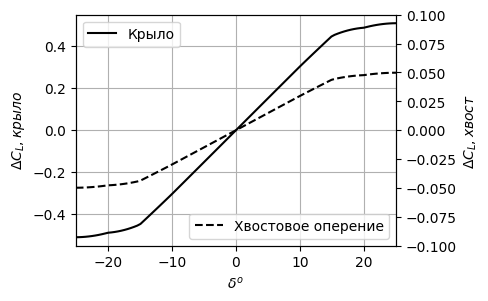

In [ ]:
hcg = 0.2
p = UAV(mass = 3.5, V = 18, CGposition = hcg, WingData=WingData, FusWidth=0.17, FusLength= 0.7, Tail = TailData, SweepQuart=False)
dcl = []
dclt = []
for el in np.linspace(-25, 25, 100):
    dcl.append(p.GetCLdelta('Wing', el))
    dclt.append(p.GetCLdelta('Tail', el)* np.cos(p.DihedraTail) * p.Sht / p.S)

f = interp1d(np.linspace(-25, 25, 100), dclt)
print((f(1) - f(-1))/(2*57.3))

fig, ax = plt.subplots(1,1, figsize=((105)/25.4,3))
ax1 = ax.twinx()
ax.plot(np.linspace(-25, 25, 100), dcl, color = 'black', label = 'Крыло')
ax1.plot(np.linspace(-25, 25, 100), dclt, '--', color = 'black', label = 'Хвостовое оперение')
ax.grid('Major')
ax.set_ylabel(r'$\Delta C_{L}, крыло$')
ax1.set_ylabel(r'$\Delta C_{L}, хвост$')
ax.set_xlabel(r'$\delta ^{o}$')
ax.legend()
ax1.legend(loc = "lower right")
ax.set_xlim(-25, 25)
ax.set_ylim(-0.55, 0.55)
ax1.set_ylim(-0.1, 0.1)
# plt.savefig('LiftIncrementDuetoLiftTailandWing.png', dpi = 300, bbox_inches = 'tight', pad_inches = 0)

In [63]:
a = np.linspace(-25, 25, 100)
(dcl[51]-dcl[50]) / (a[51] - a[50]) * 57.3

np.float64(1.7451077955085983)

Сравнение сопротивления при разных расположениях грузов

Text(0.5, 1.0, 'Зависимость коэффициента сопротивления от \n относительного удлинения фюзеляжа')

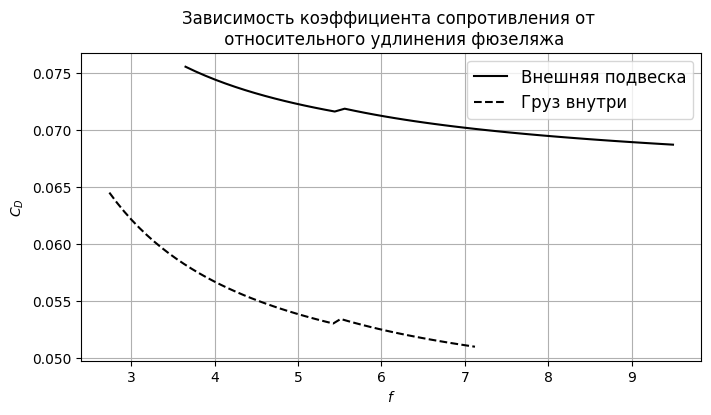

In [ ]:
S = 0.35
WingAirfoil = "SG6043"
TR = 0.75
AR = 8.
cr = 0.236
cf = 0.3
iw = 1.8 # угол установки крыла
etai = 0.5 # координата начала элеронов в ед полуразмаха
etae = 1 # координата конца элеронов в ед полуразмаха
WingData = (WingAirfoil, S, TR, AR, cr, cf, etai, etae, iw)

type = 'V'
TailAirfoil = 'NACA0008'
Vht = 0.6
Vvt = 0.04
Lt = 0.8
itail = 0 # Угол установки хвостового оперения
cf = 0.3
etaitail = 0.1 # координата начала руля высоты в ед полуразмаха
etaetail = 0.9 # координата конца руля высоты в ед полуразмаха
TailData = (type, TailAirfoil, Vht, Vvt, Lt, cf, etaitail, etaetail, itail)

Cd_payload = 2*0.8 * (0.07**2)/p.S # из численных расчтов коэффициента сопротивления в flow vision

Lf = np.linspace(0.5, 1.3, 50)
Cdf_tall = []
Cdf_small = []
d = [0.15, 0.2] # максимальная ширина фюзеляжа
for el in Lf:
    p = UAV(3.5, 18, hcg, WingData, d[1], el, TailData, cr = 0.236, SweepQuart=False)
    p.FusS = 0.74
    Cdf_tall.append(p.GetTotalDragCoefficient(0,0))
for el in Lf:
    p = UAV(3.5, 18, hcg, WingData, d[0], el, TailData, cr = 0.236, SweepQuart=False)
    p.FusS = 0.53
    Cdf_small.append(p.GetTotalDragCoefficient(0,0) + Cd_payload)
plt.figure(figsize=(8,4))
plt.plot(Lf/np.sqrt(d[0]*d[0]/1.2), Cdf_small, color = "black", linestyle = '-', label = r"Внешняя подвеска")
plt.plot(Lf/np.sqrt(d[1]*d[1]/1.2), Cdf_tall, color = "black", linestyle = '--', label = r"Груз внутри")
plt.grid("Major")
#plt.xlim(2.5, 7.5)
#plt.ylim(0.032, 0.039)
plt.xlabel(r"$f$")
plt.ylabel(r"$C_{D}$")
plt.legend(fontsize=12)
plt.title("Зависимость коэффициента сопротивления от \n относительного удлинения фюзеляжа")

Исследование формы крыла одной и той же площади ($TR \neq const, AR = const$) на аэродинамические коэффициенты. Рассматривалось крыло обособленно без учета наличия хвостового оперения и фюзеляжа. За исключением подсчета коэффициента лобового сопротивления, где был включен IF - interference factor. Как видно сужение крыла оказывает минимальное влияние на коэффициенты. 
* Крыло с сужением обладает заметной меньшим коэфф. момента тангажа по модулю
* Прямое крыло те же характеристики по сопротивлению и подъемной силе

1.7748239349298847 0.23 0.35 0.41538591169997663
1.7748239349298847 0.23 0.35 0.41538591169997663
1.7748239349298847 0.23 0.35 0.41538591169997663
1.7748239349298847 0.23 0.35 0.41538591169997663
1.7748239349298847 0.23 0.35 0.41538591169997663
1.7748239349298847 0.23 0.35 0.41538591169997663
1.7748239349298847 0.23 0.35 0.41538591169997663
1.7748239349298847 0.23 0.35 0.41538591169997663
1.7748239349298847 0.23 0.35 0.41538591169997663
1.7748239349298847 0.23 0.35 0.41538591169997663
1.7748239349298847 0.23 0.35 0.41538591169997663
1.7748239349298847 0.23 0.35 0.41538591169997663
1.7748239349298847 0.23 0.35 0.41538591169997663
1.7748239349298847 0.23 0.35 0.41538591169997663
1.7748239349298847 0.23 0.35 0.41538591169997663
1.7748239349298847 0.23 0.35 0.41538591169997663
1.7748239349298847 0.23 0.35 0.41538591169997663
1.7748239349298847 0.23 0.35 0.41538591169997663
1.7748239349298847 0.23 0.35 0.41538591169997663
1.7748239349298847 0.23 0.35 0.41538591169997663
1.7748239349298847 0

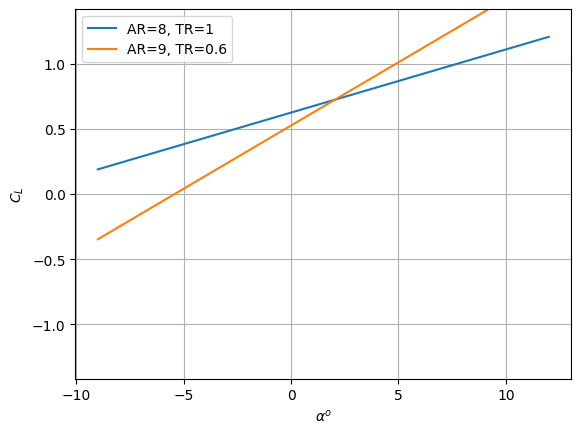

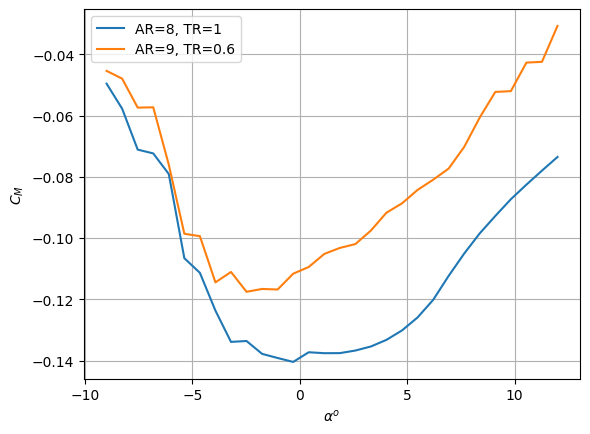

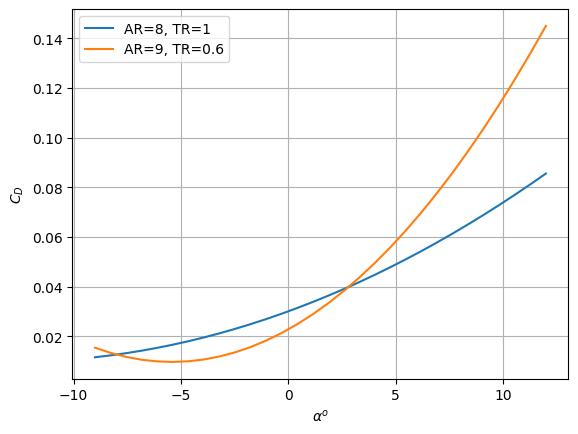

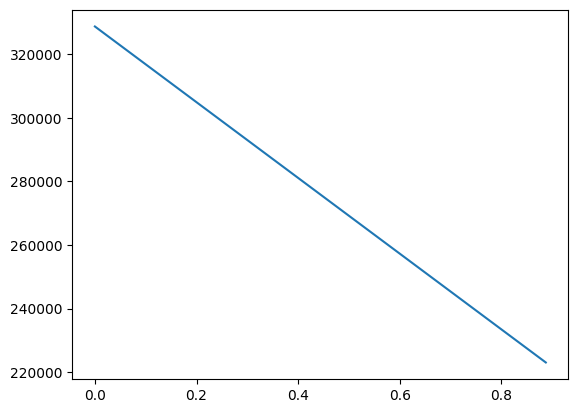

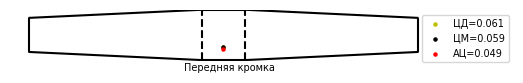

In [ ]:
AspectRatioArray = [4,5,6,7,8,9,10,11,12]

TaperRatioArray = [0.15, 0.3, 0.45, 0.6, 0.75, 0.9, 1]

AlphaArray = np.linspace(-9, 12, 30)

CD0wing = []
CDiwing = []
CLwing = []
Cmwing = []

CD0wingT = []
CDiwingT = []
CLwingT = []
CmwingT = []

for alpha in AlphaArray:
    S = 0.35
    WingAirfoil = ""
    TR = 1
    AR = 8
    cr = 0.23
    cf = 0.3
    iw = 0 # угол установки крыла
    etai = 0.5 # координата начала элеронов в ед полуразмаха
    etae = 1 # координата конца элеронов в ед полуразмаха
    WingData = (WingAirfoil, S, TR, AR, cr, cf, etai, etae, iw)

    type = 'V'
    TailAirfoil = 'NACA0008'
    Vht = 0.6
    Vvt = 0.04
    Lt = 0.8
    itail = 0 # Угол установки хвостового оперения
    cf = 0.3
    etaitail = 0.1 # координата начала руля высоты в ед полуразмаха
    etaetail = 0.9 # координата конца руля высоты в ед полуразмаха
    TailData = (type, TailAirfoil, Vht, Vvt, Lt, cf, etaitail, etaetail, itail)

    pl = UAV(3.5, 21, 0.25, WingData, 0.2, 0.7, Tail=TailData, SweepQuart=False)
    #print(pl.b, pl.cr, pl.S)
    CD0wing.append(pl.GetTotalDragCoefficient(AOA=alpha, deflec=0, distr="Wing")[0])
    CDiwing.append(pl.GetTotalDragCoefficient(AOA=alpha, deflec=0, distr="Wing")[1])
    Cmwing.append(pl.GetCm(AOA=alpha, deflec=0, distr=True)[0])
    CLwing.append(pl.GetTotalLiftCoefficient(AOA=alpha, deflecW=0, deflecT=0, distr="Wing"))

for alpha in AlphaArray:
    S = 0.35
    WingAirfoil = "SG6043"
    TRT = 0.6
    ART = 9
    cr = 0.23
    cf = 0.3
    iw = 0 # угол установки крыла
    etai = 0.5 # координата начала элеронов в ед полуразмаха
    etae = 1 # координата конца элеронов в ед полуразмаха
    WingData = (WingAirfoil, S, TRT, ART, cr, cf, etai, etae, iw)

    type = 'V'
    TailAirfoil = 'NACA0008'
    Vht = 0.6
    Vvt = 0.04
    Lt = 0.8
    itail = 0 # Угол установки хвостового оперения
    cf = 0.3
    etaitail = 0.1 # координата начала руля высоты в ед полуразмаха
    etaetail = 0.9 # координата конца руля высоты в ед полуразмаха
    TailData = (type, TailAirfoil, Vht, Vvt, Lt, cf, etaitail, etaetail, itail)

    pl = UAV(3.5, 21, 0.3, WingData, 0.2, 0.7, TailData, cr=0.23, SweepQuart=True)
    print(pl.b, pl.cr, pl.S, pl.ymgc)
    CD0wingT.append(pl.GetTotalDragCoefficient(AOA=alpha, deflec=0, distr="Wing")[0])
    CDiwingT.append(pl.GetTotalDragCoefficient(AOA=alpha, deflec=0, distr="Wing")[1])
    CmwingT.append(pl.GetCm(AOA=alpha, deflec=0, distr=True)[0])
    CLwingT.append(pl.GetTotalLiftCoefficient(AOA=alpha, deflecW=0, deflecT=0, distr="Wing"))

plt.figure()
plt.plot(AlphaArray, CLwing, label = "AR={}, TR={}".format(AR, TR))
plt.plot(AlphaArray, CLwingT, label = "AR={}, TR={}".format(ART, pl.TRT))
plt.xlabel(r"$\alpha^{o}$")
plt.ylabel(r"$C_{L}$")
plt.legend()
plt.grid()
plt.ylim(-pl.GetCLmax(), pl.GetCLmax())

plt.figure()
plt.plot(AlphaArray, Cmwing, label = "AR={}, TR={}".format(AR, TR))
plt.plot(AlphaArray, CmwingT, label = "AR={}, TR={}".format(ART, pl.TRT))
plt.legend()
plt.xlabel(r"$\alpha^{o}$")
plt.ylabel(r"$C_{M}$")
plt.grid()

plt.figure()
plt.plot(AlphaArray, np.array(CD0wing) + np.array(CDiwing), label = "AR={}, TR={}".format(AR, TR))
plt.plot(AlphaArray, np.array(CD0wingT) + np.array(CDiwingT), label = "AR={}, TR={}".format(ART, pl.TRT))
plt.legend()
plt.xlabel(r"$\alpha^{o}$")
plt.ylabel(r"$C_{D}$")
plt.grid()

plt.figure()
plt.plot(pl.GetReynoldsSpanDistribution(type="Wing")[0], pl.GetReynoldsSpanDistribution(type="Wing")[1])

pl.PlotWing()
# plt.figure()
# print(pl.GetReynolds(type="LocalW", x=0))
# plt.plot(pl.GetAirfoilWingData(y=pl.b/4)[0], pl.GetAirfoilWingData(y=pl.b/4)[1](pl.GetAirfoilWingData(y=pl.b/4)[0]))

### Модель коэффициента подъемной силы
$$C_L = C_{L_{0}} + C_{L_{\alpha}}\alpha + C_{L_{\delta_{e}}}\delta_{e} + C_{L_{q}}\frac{c}{2v_a}q$$

#### Наклон кривой коэффициента подъемной силы $C_{L_{\alpha}}$
![.](LiftCurveSlope.jpg)
![.](LiftCurveSlopeRaymer.jpg)

#### Максимально достижимый коэффициент подъемной силы крыла
Знаем распределение профильного коэффциента подъемной силы крыла. Знаем профильное распределение по размаху максимального коэфицента подъемной силы. Ищем угол атаки $\alpha_{targ}$, при котором одна из кривых для $C_l(\alpha)$ пересекает кривую $C_{l_{max}}(y)$, где y - расстояние от корневой хорды.
Фиксируем распределение $C_l(\alpha_{targ})$ и интегрируем вдоль размаха его. Получаем $C_{L_{max}}$
![.](WingMaxLiftCoefficient.png)

#### Угол атаки нулевой подъемной силы

![.](ZeroLiftCoef.jpg)

#### Коэффициент эффективности Освальда

![.](OsvaldEfficiency.jpg)

#### Требуемый коэффициент подъемной силы при заданной скорости полета и массе ЛА

![.](CruiseLiftCoefficient.jpg)


#### Приращение коэф подъемной силы профиля при отклонении управляющих поверхностей
![.](PlainFlapAirfoilLiftIncrement.png)

#### Приращение коэф подъемной силы крыла при отклонении управляющих поверхностей
![.](PlainFlapWingLiftIncrement.png)

### Модель коэффициента лобового сопротивления
$$C_D = C_{D_{0}} + C_{D{\alpha}}\alpha + C_{D_{\delta_{e}}}\delta_{e} + C_{D_{q}}\frac{c}{2v_a}q$$
Для более точной оценки лобового сопротивления в зависимости от угла атаки и геометрических характеристик ЛА используем дополненную квадратичную модель коэффициента лобового сопроивления
$$C_{D_{0}} + C_{D_{\alpha}}\alpha = C_{D}(\alpha) = C_{D_{0}} + C_{D_{i}} = C_{D_{0}} + \frac{(C_{L}(\alpha) - C_{LmD})^{2}}{\pi e AR}$$
где $C_{D_{0}}$ - паразитное сопроивление, $C_{D_{i}}$ - индуцированное сопротивление засчет подъемной силы, $e$ - коэффициент эффективности Освальда
$$C_{D_{\alpha}} = \frac{\partial C_{D}(\alpha)}{\partial \alpha} = \frac{2}{\pi e AR}(C_{L_{0}} + C_{L_{\alpha}}\alpha - C_{LmD})C_{L_{\alpha}}$$
$$C_{D_{0}} = (C_{D_{add}} + \frac{1}{S}(\sum_{i}(C_{f_{i}} \times FF_{i} \times S_{wet_{i}} \times IF_{i})))k_{crud}$$
где $C_{f}$ - коэффициент сил трения

$FF (Form factor)$ - множитель, учитывающий форму обтекаемого тела (крыла, фюзеляжа)

$S_{wet}$ - полная площадь поверхности тела, которая обтекается воздухом

$IF (Interference factor)$ - множитель, учитывающий взаимное расположение и влияние элементов на друг друга 

$C_{D_{add}}$ - дополнительный коэффициент сопротивления за счет элементов конструкции, не являющихся крылом или фюзеляжем, например, подвесных конструкций на крыле

$k_{crud}$ (Cumulative Result of Undesirable
 Drag) - множитель, учитывающий неидеальность конструкции, отличие расчетных форм поверхностей от действительных

Суммирирование производится по всем рассматриваемым элементам: крыло, фюзеляж, хвостовое оперение

#### Оценка паразитного сопротивления $C_{D_{0}}$
![.](CdminEstimationAlgorithm.jpg)

#### Фактор взаимодействия элементов конструкции между собой
![.](InterferenceFactor.jpg)

#### Неровность поверхности материала

Если понимать данные в таблице, как характерный размер неровностей на поверхности материала, то для детали изготовленной на 3Д принере-  ?
![.](SurfaceRoughness.jpg)

#### CRUD $k_{crud}$
![.](CRUDfactor.jpg)

#### Коэффициент силы трения для профиля крыла, хвостового оперения
![.](SkinFrictionCoef.jpg)

#### Оценка $C_{D_{\delta_{e}}}$
![.](CLDdeltaEstimation.png)

## Модель коэффициента момента тангажа
$$C_{m} = C_{m_{0}} + C_{m_{\alpha}}\alpha + C_{m_{\delta_{e}}}\delta_{e} + C_{m_{q}}\frac{c}{2V_{a}}q$$

#### Общий вид ЛА и обозначений для статической устойчивости
![.](GenerPlaneView.png)

#### Коэффициент момента тангажа для крыла
![.](WingPitchingMoment.png)

![.](WingZeroPitchingMomentCoeff.png)

![.](LawOfEffectiveness.png)

#### Учет коэффициента момента рыскания

![.](LatDirGeneralView.jpg)

Вклад вертикального оперения
В книге ошибка должно быть по аналогии с коэффициентом момента тангажа
$$C_{N_{VT}} = \frac{N}{qSb} = \frac{q_{VT}S_{VT}C_{L_\beta}(\beta + \sigma)L_{VT_{CG}}}{qSb} = \eta_{VT}(\frac{S_{VT}}{S})(\frac{L_{VT_{CG}}}{b})C_{L_\beta}(\beta + \sigma)$$

$$C_{N_{\beta VT}} = \eta_{VT}(\frac{S_{VT}}{S})(\frac{L_{VT_{CG}}}{b})C_{L_\beta}(1 + \frac{\partial \sigma}{\partial \beta})$$
![.](YawingMomentDueToVT.png)

Вклад крыла
![.](YawingMomentDueToWing.jpg)